# Hidden Markov Model (HMM) Analysis
### Master Thesis: Revisiting Delegation Theory in the Age of AI: Dynamic Algorithm Appreciation and Aversion in Triadic Organizational Relationships

---

### Table of Contents

**Part I — Data and HMM Estimation Framework**

1. [Data Description and Variable Construction](#1-data-description-and-variable-construction)
   - 1.1 &nbsp; [Helpers & Imports](#11-helpers--imports)
   - 1.2 &nbsp; [Benchmark Construction](#12-benchmark-construction)
   - 1.3 &nbsp; [Data Loading & Inspection](#13-data-loading--inspection)
2. [Hidden Markov Model Specification](#2-hidden-markov-model-specification)
   - 2.1 &nbsp; [Model Structure](#21-model-structure)
   - 2.2 &nbsp; [Forward–Backward Algorithm](#22-forwardbackward-algorithm)
   - 2.3 &nbsp; [Maximum Likelihood Estimation](#23-maximum-likelihood-estimation)
3. [Model Selection and Parameter Estimation](#3-model-selection-and-parameter-estimation)
4. [Posterior State Inference and Interpretation](#4-posterior-state-inference-and-interpretation)
   - 4.1 &nbsp; [Posterior State Assignment](#41-posterior-state-assignment)
   - 4.2 &nbsp; [Results Visualisation](#42-results-visualisation)

**Part II — Empirical Findings**

5. [Identification and Characterization of Three Latent Delegation States](#5-identification-and-characterization-of-three-latent-delegation-states)
6. [KPI-Driven Transition Dynamics](#6-kpi-driven-transition-dynamics)
7. [Transparency as Moderator of State Transitions](#7-transparency-as-moderator-of-state-transitions)
8. [Strategic Control Retention Under High Task Stakes](#8-strategic-control-retention-under-high-task-stakes)
9. [Non-Monotonic Relationship Between Delegation and Performance](#9-non-monotonic-relationship-between-delegation-and-performance)
10. [Robustness and Sensitivity Analyses](#10-robustness-and-sensitivity-analyses)

**Part III — Theoretical and Task-Level Implications**

11. [Delegation as Dynamic Learning Process](#11-delegation-as-dynamic-learning-process)
12. [Authority as Strategic and Legitimacy Mechanism](#12-authority-as-strategic-and-legitimacy-mechanism)
13. [Triadic Delegation Flows: Authority vs Execution](#13-triadic-delegation-flows-authority-vs-execution)
14. [Temporal Evolution of Delegation Patterns](#14-temporal-evolution-of-delegation-patterns)

---
# Part I — Data and HMM Estimation Framework

## 1. Data Description and Variable Construction
### 1.1 Helpers & Imports

In [1]:
# ============================================================
# 1. Imports & Helpers
# ============================================================
from __future__ import annotations

import os
import time
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple
from pathlib import Path
from multiprocessing.pool import ThreadPool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# ---- resolve data path ----
MANUAL_XLSX_PATH = None
PREFERRED_DATASETS = [
    Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx"),
]
DATA_PATH = None
if MANUAL_XLSX_PATH:
    DATA_PATH = Path(MANUAL_XLSX_PATH)
else:
    for p in PREFERRED_DATASETS:
        if p.exists():
            DATA_PATH = p
            break
assert DATA_PATH is not None and DATA_PATH.exists(), \
    f"Data file not found. Tried: {PREFERRED_DATASETS}"
print(f"Data file: {DATA_PATH.resolve()}")


def softmax(z, axis=-1):
    """Numerically stable softmax (works on 1-D vectors and row-wise on 2-D)."""
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)


def log_softmax(z, axis=-1):
    """Numerically stable log-softmax."""
    return z - logsumexp(z, axis=axis, keepdims=True)


def log_gaussian_diag(y, mean, log_sigma):
    """Scalar version (kept for reference)."""
    sigma2 = np.exp(2 * log_sigma)
    return -0.5 * (
        np.sum(np.log(2 * np.pi * sigma2))
        + np.sum((y - mean) ** 2 / sigma2)
    )

print("Section 1 — Imports & helpers loaded.")

Data file: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx
Section 1 — Imports & helpers loaded.


### 1.2 Benchmark Construction
Derive performance benchmarks used as **transition covariates**:
- `kpi_operational_gap_index` — composite operational KPIs gap
- `within_unit_temporal_benchmark` — period-over-period KPIs change
- `horizontal_peer_benchmark` — cross-sectional percentile, rank percentile within period
- `within_unit_ai_trajectory_benchmark` — deviation from low-AI baseline (periods with low AI delegation)
- `threshold_benchmark` — recent negative shock indicator, e.g. missing a KPI target, a self-service level breach or forecast failure in the preceding period.

In [ ]:
# ============================================================
# 2. Build Benchmarks
# ============================================================

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()

    # Composite performance index (higher = better)
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )

    # Within-manager temporal benchmark
    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )

    # Peer percentile (cross-sectional)
    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0

    # AI trajectory benchmark
    def ai_traj(g):
        q = g["ai_decision_authority_share"].quantile(0.30)
        base = g.loc[
            g["ai_decision_authority_share"] <= q,
            "kpi_operational_gap_index",
        ].mean()
        if np.isnan(base):
            base = g["kpi_operational_gap_index"].mean()
        return g["kpi_operational_gap_index"] - base

    df["within_unit_ai_trajectory_benchmark"] = (
        df.groupby("manager_id", group_keys=False).apply(ai_traj)
    )

    # Threshold shock
    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)

    # Transparency constant (analysis dataset — no variation)
    df["transparency_moderator"] = 0.0

    return df

print("Section 2 — build_benchmarks() defined.")

Section 2 — build_benchmarks() defined.


### 1.3 Data Loading & Inspection
Load the `panel_manager_period` sheet, build benchmarks, scale variables, and form per-manager sequences.

In [17]:
# ============================================================
# 3. Data Loader
# ============================================================

@dataclass
class HMMData:
    Y: List[np.ndarray]      # emission sequences
    X: List[np.ndarray]      # transition covariates
    Z: List[np.ndarray]      # emission controls
    ids: List[str]
    periods: List[np.ndarray]
    y_scaler: StandardScaler
    x_scaler: StandardScaler
    z_scaler: StandardScaler


def load_sequences(xlsx_path):
    df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")

    # Safety: analysis file should NOT contain latent truth columns
    forbidden = ["latent_state_true", "latent_state_true_next"]
    if any(c in df.columns for c in forbidden):
        raise ValueError("Use *_ANALYSIS.xlsx dataset (latent states removed).")

    df = build_benchmarks(df)

    # ── Compute share_authority_esc from decision_episode ──
    dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
    dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
    esc_agg = (dec_ep
        .groupby(["manager_id", "period_id"])
        .agg(n_tasks=("episode_id", "count"),
             n_escalated=("is_escalated", "sum"))
        .reset_index())
    esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
    df = df.merge(esc_agg[["manager_id", "period_id", "share_authority_esc"]],
                  on=["manager_id", "period_id"], how="left")
    df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)
    print(f"  share_authority_esc computed from decision_episode "
          f"(mean={df['share_authority_esc'].mean():.4f}, "
          f"std={df['share_authority_esc'].std():.4f})")

    emission_cols = ["ai_decision_authority_share", "override_rate",
                     "share_authority_esc"]

    transition_cols = [
        "within_unit_temporal_benchmark",
        "horizontal_peer_benchmark",
        "within_unit_ai_trajectory_benchmark",
        "threshold_benchmark",
        "transparency_moderator",
    ]

    control_cols = [
        "task_complexity_index",
        "demand_volatility",
        "supply_disruption_count",
        "forecast_accuracy_mape",
        "decision_latency_avg",
        "target_difficulty",
        "performance_pressure_index",
        "recent_negative_shock",
    ]

    df = df.dropna(subset=emission_cols + transition_cols + control_cols)

    Y_list, X_list, Z_list = [], [], []
    ids, periods = [], []

    for mid, g in df.groupby("manager_id"):
        g = g.sort_values("period_id")
        Y = g[emission_cols].to_numpy(float)
        X = g[transition_cols].to_numpy(float)
        Z = g[control_cols].to_numpy(float)
        if len(Y) < 3:
            continue
        Y_list.append(Y)
        X_list.append(X)
        Z_list.append(Z)
        ids.append(mid)
        periods.append(g["period_id"].to_numpy())

    y_scaler = StandardScaler().fit(np.vstack(Y_list))
    x_scaler = StandardScaler().fit(np.vstack(X_list))
    z_scaler = StandardScaler().fit(np.vstack(Z_list))

    Y_list = [y_scaler.transform(y) for y in Y_list]
    X_list = [x_scaler.transform(x) for x in X_list]
    Z_list = [z_scaler.transform(z) for z in Z_list]

    return HMMData(Y_list, X_list, Z_list, ids, periods,
                   y_scaler, x_scaler, z_scaler)


# ---- Load & inspect ----
data = load_sequences(DATA_PATH)

seq_lens = [len(y) for y in data.Y]
print(f"Managers loaded : {len(data.Y)}")
print(f"Total observations: {sum(seq_lens)}")
print(f"Sequence lengths : min={min(seq_lens)}, median={int(np.median(seq_lens))}, max={max(seq_lens)}")
print(f"Emission dims (D) : {data.Y[0].shape[1]}")
print(f"Trans. covars (P) : {data.X[0].shape[1]}")
print(f"Controls (K)      : {data.Z[0].shape[1]}")

  share_authority_esc computed from decision_episode (mean=0.1765, std=0.0737)
Managers loaded : 120
Total observations: 3000
Sequence lengths : min=25, median=25, max=25
Emission dims (D) : 3
Trans. covars (P) : 5
Controls (K)      : 8


## 2. Hidden Markov Model Specification
### 2.1 Model Structure & 2.2 Forward–Backward Algorithm
#### 2.1 Model Structure
We use an Input–Output Hidden Markov Model (IO-HMM) to represent unobserved delegation regimes (hidden states) that managers move between over time. All model parameters are stored in a single Params container so they can be easily passed to the optimizer and consistently used across the likelihood computation.

Params includes three parts:

- Initial state distribution (logit_pi)
Controls the probability of starting in each hidden state at the first period.

- Transition model (alpha, beta)
Controls how likely the model is to move from one hidden state to another.

    - alpha captures baseline persistence/switching (e.g., tendency to stay in the same state).

    - beta captures how period-level covariates x_t (your benchmark/pressure variables) shift transition probabilities over time. Because transitions depend on inputs, the model is “input–output” (non-homogeneous).

- Emission model (mu, W, log_sigma)
Links hidden states to observed outcomes y_t.

    - mu is the baseline mean outcome pattern for each state.

    - W captures how contextual variables z_t shift outcomes within each state.

    - log_sigma stores (log) standard deviations to keep variances positive and stable.

#### 2.2 Forward-Backward Algorithm
Hidden states are not observed, so we cannot evaluate the likelihood by directly enumerating all possible state sequences (that would explode combinatorially). The forward–backward algorithm solves this efficiently.

- Forward pass (main purpose in your MLE code)
Computes the likelihood of the observed data by recursively updating “how probable it is to be in each state at time t,” given all data up to time t. This is what you use to compute the log-likelihood during optimization.

- Backward pass (optional but standard)
Works from the end back to the start to compute posterior quantities (e.g., probability of each state at each time), which are useful for interpretation, diagnostics, and plotting state occupancy.

- Scaling for numerical stability
Multiplying many probabilities across time can underflow to zero in floating-point arithmetic. Scaling rescales intermediate values each period and accumulates the log-likelihood safely, preventing numerical issues and improving convergence.

In [4]:
# ============================================================
# 4. Parameters + Forward–Backward  (VECTORIZED)
# ============================================================

@dataclass
class Params:
    logit_pi: np.ndarray   # (J,)
    alpha: np.ndarray      # (J, J)
    beta: np.ndarray       # (J, J, P)
    mu: np.ndarray         # (J, D)
    W: np.ndarray          # (J, D, K)
    log_sigma: np.ndarray  # (J, D)


def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] +
                   np.sum(residuals ** 2 / sigma2[None, :, :], axis=2))
    logits_all = (p.alpha[None, :, :]
                  + np.einsum('ijp,tp->tij', p.beta, X))
    logQ_all = log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all


def forward_only(p, Y, X, Z):
    """Forward pass only — returns log-likelihood (no posterior). ~2× faster."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    return float(logsumexp(log_alpha[-1]))


def forward_backward(p, Y, X, Z):
    """Full forward–backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1)

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma

print("Section 4 — Params, forward_only() & forward_backward() defined.")

Section 4 — Params, forward_only() & forward_backward() defined.


### 2.3 Maximum Likelihood Estimation
Estimate models with 2–4 latent states via maximum likelihood using L-BFGS-B optimization. To mitigate local optima, we employ multiple random initializations and diagonal-biased transition logits. Model selection follows a two-stage procedure: a computationally efficient screening phase identifies the most promising state specification using BIC, followed by a high-precision refit of the selected model using extended iterations and warm-start initialization. The final model is chosen based on the lowest Bayesian Information Criterion.

In [7]:
# ============================================================
# IO-HMM (3 emissions) — FAST + MORE RELIABLE CONVERGENCE
# Fixes:
#   (A) time-cap bug: true_negll computed with stop_flag reset
#   (B) J=3 warm start via EMISSIONS-ONLY prefit (beta=W=0)
#   (C) faster screening: allow subset for J=3, but final run uses full data
# ============================================================

import time
import numpy as np
import pandas as pd
from dataclasses import dataclass
from scipy.optimize import minimize
from scipy.special import logsumexp, log_softmax
from sklearn.cluster import KMeans

# ----------------------------
# Params container
# ----------------------------
@dataclass
class Params:
    logit_pi: np.ndarray   # (J,)
    alpha: np.ndarray      # (J,J)
    beta: np.ndarray       # (J,J,P)
    mu: np.ndarray         # (J,D)
    W: np.ndarray          # (J,D,K)
    log_sigma: np.ndarray  # (J,D)

# ----------------------------
# Assume you already have:
#   Y_stack: (N,T,D)  with D=3
#   X_stack: (N,T,P)
#   Z_stack: (N,T,K)
# ----------------------------
N, T, D = Y_stack.shape
P = X_stack.shape[2]
K = Z_stack.shape[2]
n_obs_total = N * T

def fit_model_batched(
    J: int,
    Y_stack: np.ndarray,
    X_stack: np.ndarray,
    Z_stack: np.ndarray,
    maxiter: int = 600,
    n_starts: int = 5,
    seed: int = 7,
    sigma_min: float = 0.05,
    sigma_max: float = 5.0,
    time_cap_min: int = 15,
    print_every: int = 50,
    l2: float = 1e-4,
    diag_bias: float = 2.0,
    maxfun: int = 200000,
    ftol: float = 1e-8,
    gtol: float = 5e-6,
    warm_starts: list | None = None,
    use_subset: bool = False,
    subset_size: int = 60,
    # NEW:
    do_emission_only_warmstart: bool = True,
    emission_only_maxiter: int = 120,
    emission_only_maxfun: int = 60000,
):
    """
    Batched NH-HMM fit with Gaussian emissions + covariate-dependent transitions.

    NEW improvements:
      1) Emissions-only warm-start (beta=W=0) to stabilize J=3.
      2) FIX: compute true_negll with stop_flag reset.
    """

    N, T, D = Y_stack.shape
    P = X_stack.shape[2]
    K = Z_stack.shape[2]

    # ----------------------------
    # Choose data (subset optional)
    # ----------------------------
    if use_subset and N > subset_size:
        rng_sub = np.random.default_rng(seed)
        idx = rng_sub.choice(N, size=subset_size, replace=False)
        Y_use = Y_stack[idx]
        X_use = X_stack[idx]
        Z_use = Z_stack[idx]
        N_use = subset_size
    else:
        Y_use, X_use, Z_use = Y_stack, X_stack, Z_stack
        N_use = N

    # ----------------------------
    # pack / unpack
    # ----------------------------
    def pack(p: Params) -> np.ndarray:
        return np.concatenate([
            p.logit_pi.ravel(),
            p.alpha.ravel(),
            p.beta.ravel(),
            p.mu.ravel(),
            p.W.ravel(),
            p.log_sigma.ravel(),
        ])

    def unpack(theta: np.ndarray) -> Params:
        idx = 0
        def take(n: int) -> np.ndarray:
            nonlocal idx
            v = theta[idx:idx+n]
            idx += n
            return v
        return Params(
            logit_pi=take(J),
            alpha=take(J*J).reshape(J, J),
            beta=take(J*J*P).reshape(J, J, P),
            mu=take(J*D).reshape(J, D),
            W=take(J*D*K).reshape(J, D, K),
            log_sigma=take(J*D).reshape(J, D),
        )

    # ----------------------------
    # bounds for log_sigma only
    # ----------------------------
    n_logit_pi = J
    n_alpha = J * J
    n_beta = J * J * P
    n_mu = J * D
    n_W = J * D * K
    n_log_sigma = J * D

    log_sigma_start = n_logit_pi + n_alpha + n_beta + n_mu + n_W
    log_sigma_end   = log_sigma_start + n_log_sigma
    total_params    = log_sigma_end

    LOW, HIGH = np.log(sigma_min), np.log(sigma_max)

    bounds = [(None, None)] * total_params
    for i in range(log_sigma_start, log_sigma_end):
        bounds[i] = (LOW, HIGH)

    # ----------------------------
    # init helpers (BETTER FOR J=3)
    # - use kmeans on actual Y points for mu init
    # ----------------------------
    Y_flat = Y_use.reshape(-1, D)
    y_std  = np.maximum(Y_flat.std(axis=0), 1e-3)

    def kmeans_init_params(rng: np.random.Generator) -> Params:
        km = KMeans(n_clusters=J, n_init=5, random_state=int(rng.integers(1_000_000)))
        labels = km.fit_predict(Y_flat)
        mu0 = km.cluster_centers_.copy()

        # per-cluster sigma
        sig0 = np.zeros((J, D))
        for j in range(J):
            pts = Y_flat[labels == j]
            if pts.shape[0] < 10:
                sig0[j] = y_std
            else:
                sig0[j] = np.maximum(pts.std(axis=0), 1e-3)
        log_sigma0 = np.clip(np.log(np.clip(sig0, sigma_min, sigma_max)), LOW, HIGH)

        logit_pi0 = rng.normal(0, 0.2, J)
        alpha0 = rng.normal(0, 0.2, (J, J))
        alpha0 += np.eye(J) * diag_bias

        beta0 = rng.normal(0, 0.01, (J, J, P))
        W0    = rng.normal(0, 0.01, (J, D, K))

        return Params(logit_pi0, alpha0, beta0, mu0, W0, log_sigma0)

    # ----------------------------
    # Time-cap stop flag
    # ----------------------------
    stop_flag = {"stop": False}

    # ----------------------------
    # neg log-likelihood
    # ----------------------------
    def neg_ll(theta: np.ndarray) -> float:
        if stop_flag["stop"]:
            return 1e50

        p = unpack(theta)
        log_pi = log_softmax(p.logit_pi, axis=0)  # (J,)

        means = p.mu[None, None, :, :] + np.einsum("jdk,ntk->ntjd", p.W, Z_use)  # (N_use,T,J,D)
        resid = Y_use[:, :, None, :] - means

        sigma2 = np.exp(2.0 * p.log_sigma)
        sigma2 = np.maximum(sigma2, 1e-6)

        log_norm = np.sum(np.log(2.0 * np.pi * sigma2), axis=1)  # (J,)
        logB = -0.5 * (
            log_norm[None, None, :] +
            np.sum(resid**2 / sigma2[None, None, :, :], axis=3)
        )  # (N_use,T,J)

        logQ = log_softmax(
            p.alpha[None, None, :, :] + np.einsum("ijp,ntp->ntij", p.beta, X_use),
            axis=3
        )  # (N_use,T,J,J)

        la = log_pi[None, :] + logB[:, 0, :]
        for t in range(1, T):
            la = logB[:, t, :] + logsumexp(la[:, :, None] + logQ[:, t, :, :], axis=1)

        ll = np.sum(logsumexp(la, axis=1))
        if not np.isfinite(ll):
            return 1e40
        return -float(ll)

    def objective(theta: np.ndarray) -> float:
        base = neg_ll(theta)
        if not np.isfinite(base):
            return 1e40
        if l2 <= 0:
            return base
        p = unpack(theta)
        pen = (
            np.sum(p.alpha**2) +
            np.sum(p.beta**2) +
            np.sum(p.W**2) +
            0.10 * np.sum(p.mu**2)
        )
        return base + l2 * pen

    # ----------------------------
    # Emissions-only warm start (beta=W forced to 0)
    # ----------------------------
    def emission_only_warmstart(p0: Params) -> Params:
        p_init = Params(
            logit_pi=p0.logit_pi.copy(),
            alpha=p0.alpha.copy(),
            beta=np.zeros_like(p0.beta),
            mu=p0.mu.copy(),
            W=np.zeros_like(p0.W),
            log_sigma=p0.log_sigma.copy(),
        )

        theta0 = pack(p_init)

        # bounds still apply (log_sigma)
        def neg_ll_emiss(theta):
            # unpack then force beta=W=0 inside evaluation
            p = unpack(theta)
            p.beta[:] = 0.0
            p.W[:] = 0.0
            return neg_ll(pack(p))

        res = minimize(
            neg_ll_emiss,
            theta0,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": emission_only_maxiter, "maxfun": emission_only_maxfun, "ftol": 1e-8, "gtol": 1e-6},
        )

        p_hat = unpack(res.x)
        p_hat.beta[:] = 0.0
        p_hat.W[:] = 0.0
        return p_hat

    # ----------------------------
    # multi-start optimization
    # ----------------------------
    init_list = []
    if warm_starts:
        init_list.extend(warm_starts)

    runs = []

    for s in range(n_starts):
        rng = np.random.default_rng(seed + s)
        stop_flag["stop"] = False

        if s < len(init_list):
            p0 = init_list[s]
        else:
            p0 = kmeans_init_params(rng)

        # Do emissions-only warm start ONLY for J>=3 (helps most there)
        if do_emission_only_warmstart and J >= 3 and (s == 0):
            p0 = emission_only_warmstart(p0)

        # small jitter
        p0 = Params(
            logit_pi=p0.logit_pi + rng.normal(0, 0.02, J),
            alpha=p0.alpha + rng.normal(0, 0.02, (J, J)),
            beta=p0.beta + rng.normal(0, 0.006, (J, J, P)),
            mu=p0.mu + rng.normal(0, 0.03, (J, D)),
            W=p0.W + rng.normal(0, 0.006, (J, D, K)),
            log_sigma=np.clip(p0.log_sigma + rng.normal(0, 0.015, (J, D)), LOW, HIGH),
        )

        theta0 = pack(p0)
        start_time = time.time()
        iter_counter = {"i": 0}

        def callback(_xk):
            iter_counter["i"] += 1
            if iter_counter["i"] % print_every == 0:
                elapsed_min = (time.time() - start_time) / 60
                print(f"    J={J} start {s+1}/{n_starts} iter={iter_counter['i']} elapsed={elapsed_min:.1f} min", flush=True)
            if (time.time() - start_time) > time_cap_min * 60:
                stop_flag["stop"] = True

        res = minimize(
            objective,
            theta0,
            method="L-BFGS-B",
            bounds=bounds,
            callback=callback,
            options={"maxiter": maxiter, "maxfun": maxfun, "ftol": ftol, "gtol": gtol},
        )

        hit_time_cap = bool(stop_flag["stop"])
        if hit_time_cap:
            res.success = False
            res.message = f"Per-start time cap reached ({time_cap_min} min)"

        # -------- FIX BUG: recompute true negLL with stop_flag reset ----------
        stop_flag["stop"] = False
        true_negll = neg_ll(res.x)

        runs.append((unpack(res.x), res, true_negll))

        print(
            f"    done: J={J} start {s+1}/{n_starts} success={res.success} "
            f"nit={getattr(res,'nit',None)} true_negLL={true_negll:.2f} msg={res.message}",
            flush=True
        )

    converged = [(p_hat, r, tnl) for (p_hat, r, tnl) in runs if bool(r.success)]
    if len(converged) > 0:
        best_p, best_res, best_true_negll = min(converged, key=lambda t: t[2])
        best_is_converged = True
    else:
        best_p, best_res, best_true_negll = min(runs, key=lambda t: t[2])
        best_is_converged = False

    best_res.true_negll = best_true_negll
    best_res.true_ll = -best_true_negll
    best_res.k_params = len(best_res.x)
    return best_p, best_res, best_is_converged


# ============================================================
# STAGE 1: Screening (FASTER + J=3 gets a real chance)
# ============================================================
screen_results = []

print("\n=== STAGE 1: Screening (D=3; faster + reliable J=3) ===")
for J in [2, 3, 4]:
    if J == 2:
        # J=2 already converges for you; keep cheap-ish
        cfg = dict(maxiter=450, n_starts=4, time_cap_min=10, diag_bias=2.2, maxfun=140000,
                   use_subset=False, l2=1e-4, do_emission_only_warmstart=False)
    elif J == 3:
        # KEY: emissions-only warmstart + allow subset to speed screening
        cfg = dict(maxiter=550, n_starts=4, time_cap_min=14, diag_bias=2.8, maxfun=220000,
                   use_subset=True, subset_size=70, l2=1e-4, do_emission_only_warmstart=True)
    else:  # J=4
        cfg = dict(maxiter=550, n_starts=3, time_cap_min=14, diag_bias=3.0, maxfun=260000,
                   use_subset=True, subset_size=60, l2=2e-4, do_emission_only_warmstart=True)

    print(f"\n[Screen] Fitting J={J} ...", flush=True)
    t0 = time.time()

    p_hat, res, is_conv = fit_model_batched(
        J=J, Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=7, sigma_min=0.1, sigma_max=3.0, print_every=50, ftol=1e-8, gtol=5e-6,
        **cfg
    )

    elapsed = time.time() - t0
    ll_total = res.true_ll
    k_params = len(res.x)
    bic = np.log(n_obs_total) * k_params - 2 * ll_total
    aic = 2 * k_params - 2 * ll_total

    screen_results.append({
        "stage": "screen",
        "J": J,
        "params": k_params,
        "LL": ll_total,
        "AIC": aic,
        "BIC": bic,
        "converged": bool(res.success),
        "selected_converged_run": bool(is_conv),
        "time_s": elapsed,
        "message": str(res.message),
    })

    print(f"[Screen] J={J} LL={ll_total:.1f} BIC={bic:.1f} params={k_params} "
          f"{'✓' if res.success else '✗'} ({elapsed/60:.1f} min)")
    print(f"         message: {res.message}")

df_screen = pd.DataFrame(screen_results)
display(df_screen.round(2))

# choose best (prefer converged)
df_conv = df_screen[df_screen["converged"] == True]
best_row = df_conv.loc[df_conv["BIC"].idxmin()] if len(df_conv) else df_screen.loc[df_screen["BIC"].idxmin()]
best_J_screen = int(best_row["J"])
print(f"\n★ Screening winner: J={best_J_screen} (BIC={best_row['BIC']:.1f}, converged={best_row['converged']})")


# ============================================================
# STAGE 2: Final refit for J=3 (FORCED) to get at least one converged run
# ============================================================
print("\n=== STAGE 2: Forced Final Refit for J=3 (full data) ===")
t0 = time.time()

# Warm start (emissions-only) then full fit
p3_warm, res3_warm, _ = fit_model_batched(
    J=3, Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
    maxiter=250, n_starts=1, seed=999, time_cap_min=12, diag_bias=2.8, maxfun=120000,
    use_subset=False, l2=2e-4, do_emission_only_warmstart=True
)

best_p3, best_res3, best_is_conv3 = fit_model_batched(
    J=3, Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
    maxiter=950, n_starts=6, seed=77, time_cap_min=22, diag_bias=1.8, maxfun=420000,
    use_subset=False, l2=5e-5, do_emission_only_warmstart=False,
    warm_starts=[p3_warm]
)

elapsed = time.time() - t0
ll_total = best_res3.true_ll
k_params = len(best_res3.x)
bic = np.log(n_obs_total) * k_params - 2 * ll_total
aic = 2 * k_params - 2 * ll_total

print(f"\n[Final J=3] LL={ll_total:.1f} AIC={aic:.1f} BIC={bic:.1f} params={k_params} "
      f"{'✓' if best_res3.success else '✗'} ({elapsed/60:.1f} min)")
print(f"message: {best_res3.message}")



=== STAGE 1: Screening (D=3; faster + reliable J=3) ===

[Screen] Fitting J=2 ...
    J=2 start 1/4 iter=50 elapsed=0.8 min
    J=2 start 1/4 iter=100 elapsed=1.6 min
    J=2 start 1/4 iter=150 elapsed=2.3 min
    done: J=2 start 1/4 success=True nit=199 true_negLL=1151.78 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 2/4 iter=50 elapsed=0.8 min
    J=2 start 2/4 iter=100 elapsed=1.5 min
    J=2 start 2/4 iter=150 elapsed=2.1 min
    J=2 start 2/4 iter=200 elapsed=2.9 min
    done: J=2 start 2/4 success=True nit=204 true_negLL=1151.78 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 3/4 iter=50 elapsed=0.8 min
    J=2 start 3/4 iter=100 elapsed=1.4 min
    J=2 start 3/4 iter=150 elapsed=2.2 min
    done: J=2 start 3/4 success=True nit=199 true_negLL=1151.78 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 4/4 iter=50 elapsed=0.8 min
    J=2 start 4/4 iter=100 elapsed=1.7 min
    J=2 start 4/4 iter=150 elapsed=2.3 min

KeyboardInterrupt: 

In [12]:
# ============================================================
# STAGE 1: Screening — subset fits to GET stable warm starts
# ============================================================
screen_results = []
warm_by_J = {}

print("\n=== STAGE 1A: Subset Screening (get at least 1 converged run per J) ===")

for J in [2, 3, 4]:
    if J == 2:
        cfg = dict(
            maxiter=600,
            n_starts=6,
            time_cap_min=15,
            diag_bias=2.0,
            maxfun=220000,
            use_subset=False,      # J=2 full data directly
            subset_size=80,
            l2=5e-5,
            ftol=1e-7,
            gtol=1e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=140,
        )
    elif J == 3:
        cfg = dict(
            maxiter=900,
            n_starts=10,           # more starts
            time_cap_min=25,       # more time
            diag_bias=2.6,
            maxfun=380000,
            use_subset=True,
            subset_size=95,        # larger subset
            l2=8e-5,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=180,
        )
    else:  # J=4
        cfg = dict(
            maxiter=1100,
            n_starts=12,           # more starts
            time_cap_min=30,       # more time
            diag_bias=2.9,
            maxfun=520000,
            use_subset=True,
            subset_size=95,        # larger subset
            l2=8e-5,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=220,
        )

    print(f"\n[SubsetScreen] Fitting J={J} ...", flush=True)
    t0 = time.time()

    p_hat_sub, res_sub, is_conv_sub = fit_model_batched(
        J=J,
        Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=7, sigma_min=0.1, sigma_max=3.5, print_every=50,
        **cfg
    )

    elapsed = time.time() - t0
    warm_by_J[J] = p_hat_sub  # store warm start regardless (best run)

    print(f"[SubsetScreen] J={J} soft_converged={is_conv_sub} "
          f"LL={res_sub.true_ll:.1f} ({elapsed/60:.1f} min) msg={res_sub.message}")

print("\n=== STAGE 1B: Full-data Screening (using subset warm starts) ===")

for J in [2, 3, 4]:
    # Full data run, seeded with warm start from Stage 1A
    if J == 2:
        cfg_full = dict(
            maxiter=700,
            n_starts=6,
            time_cap_min=18,
            diag_bias=2.0,
            maxfun=260000,
            use_subset=False,
            l2=5e-5,
            ftol=1e-7,
            gtol=1e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=140,
        )
    elif J == 3:
        cfg_full = dict(
            maxiter=1200,
            n_starts=10,
            time_cap_min=32,
            diag_bias=2.4,
            maxfun=520000,
            use_subset=False,
            l2=8e-5,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=200,
        )
    else:
        cfg_full = dict(
            maxiter=1500,
            n_starts=12,
            time_cap_min=40,
            diag_bias=2.7,
            maxfun=700000,
            use_subset=False,
            l2=8e-5,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=260,
        )

    print(f"\n[ScreenFull] Fitting J={J} (warm-started) ...", flush=True)
    t0 = time.time()

    p_hat, res, is_conv = fit_model_batched(
        J=J,
        Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=77, sigma_min=0.1, sigma_max=3.5, print_every=50,
        warm_starts=[warm_by_J[J]],   # <<< the important part
        **cfg_full
    )

    elapsed = time.time() - t0
    ll_total = res.true_ll
    k_params = len(res.x)

    # NOTE: use global n_obs_total for AIC/BIC on full data
    bic = np.log(n_obs_total) * k_params - 2 * ll_total
    aic = 2 * k_params - 2 * ll_total

    screen_results.append({
        "stage": "screen_full",
        "J": J,
        "params": k_params,
        "LL": ll_total,
        "AIC": aic,
        "BIC": bic,
        "converged_soft": bool(is_conv),
        "converged_scipy": bool(getattr(res, "success", False)),
        "time_s": elapsed,
        "message": str(res.message),
    })

    conv_symbol = "✓" if is_conv else "✗"
    print(f"[ScreenFull] J={J} LL={ll_total:.1f} BIC={bic:.1f} params={k_params} "
          f"{conv_symbol} ({elapsed/60:.1f} min)")
    print(f"            message: {res.message}")

df_screen = pd.DataFrame(screen_results)
display(df_screen.round(2))

# Check if J=3 and J=4 converged (soft)
j3_ok = df_screen[df_screen["J"] == 3]["converged_soft"].values[0]
j4_ok = df_screen[df_screen["J"] == 4]["converged_soft"].values[0]
print(f"\nConvergence check (soft): J=3: {j3_ok}  J=4: {j4_ok}")

# Choose best by BIC among soft-converged; fall back to all if none
df_conv = df_screen[df_screen["converged_soft"] == True]
if len(df_conv) > 0:
    best_row = df_conv.loc[df_conv["BIC"].idxmin()]
else:
    best_row = df_screen.loc[df_screen["BIC"].idxmin()]
    print("⚠️  No soft-converged models! Selecting best by BIC anyway.")

best_J_screen = int(best_row["J"])
print(f"\n★ Screening winner: J={best_J_screen} (BIC={best_row['BIC']:.1f}, soft_converged={best_row['converged_soft']})")



=== STAGE 1A: Subset Screening (get at least 1 converged run per J) ===

[SubsetScreen] Fitting J=2 ...
    J=2 start 1/6 iter=50 elapsed=0.8 min
    J=2 start 1/6 iter=100 elapsed=1.4 min
    J=2 start 1/6 iter=150 elapsed=1.9 min
    J=2 start 1/6 iter=200 elapsed=2.8 min
    done: J=2 start 1/6 success=True soft_conv=True nit=200 true_negLL=1151.78 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 2/6 iter=50 elapsed=1.2 min
    J=2 start 2/6 iter=100 elapsed=2.1 min
    J=2 start 2/6 iter=150 elapsed=2.8 min
    done: J=2 start 2/6 success=True soft_conv=True nit=198 true_negLL=1151.78 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 3/6 iter=50 elapsed=0.7 min
    J=2 start 3/6 iter=100 elapsed=1.3 min
    J=2 start 3/6 iter=150 elapsed=2.1 min
    done: J=2 start 3/6 success=True soft_conv=True nit=162 true_negLL=1151.79 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=2 start 4/6 iter=50 elapsed=0.6 min
    J=2 start 4/6 

KeyboardInterrupt: 

In [18]:
# ============================================================
# STAGE 1B ONLY — FAST Full-data Screening (warm-started)
# Assumes: warm_by_J already exists from Stage 1A (keys 2,3,4)
# ============================================================

screen_results = []

def run_full_once(J, cfg_full, seed, warm):
    """Run fit_model_batched with exactly ONE start (n_starts forced to 1)."""
    cfg1 = dict(cfg_full)
    cfg1["n_starts"] = 1
    return fit_model_batched(
        J=J,
        Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
        seed=seed, sigma_min=0.1, sigma_max=3.5,
        print_every=50,
        warm_starts=[warm],
        **cfg1
    )

print("\n=== STAGE 1B: Full-data Screening (FAST; 1–2 starts per J) ===")

for J in [2, 3, 4]:
    # Much smaller budgets than your original Stage 1B
    # (Full-data fit should NOT have 6/10/12 restarts)
    if J == 2:
        cfg_full = dict(
            maxiter=600,
            time_cap_min=20,      # allow a bit more than 18 so J=2 can finish
            diag_bias=2.0,
            maxfun=220000,
            use_subset=False,
            l2=5e-5,
            ftol=1e-7,
            gtol=1e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=140,
        )
        backup_seed = 177
    elif J == 3:
        cfg_full = dict(
            maxiter=800,
            time_cap_min=25,      # keep bounded
            diag_bias=2.4,
            maxfun=320000,
            use_subset=False,
            l2=8e-5,
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=200,
        )
        backup_seed = 277
    else:  # J=4
        cfg_full = dict(
            maxiter=1000,
            time_cap_min=30,      # IMPORTANT: bounded; J=4 can otherwise run forever
            diag_bias=2.8,
            maxfun=420000,
            use_subset=False,
            l2=1.2e-4,            # slightly stronger reg helps stability at J=4
            ftol=1e-7,
            gtol=2e-5,
            do_emission_only_warmstart=True,
            emission_only_maxiter=240,
        )
        backup_seed = 377

    print(f"\n[ScreenFull] Fitting J={J} (warm-started) ...", flush=True)
    t0 = time.time()

    warm = warm_by_J.get(J)
    if warm is None:
        print(f"    ⚠️ No warm start available for J={J}; skipping this J.", flush=True)
        continue

    # --- attempt 1
    p_hat, res, is_conv = run_full_once(J, cfg_full, seed=77, warm=warm)

    # --- optional attempt 2 (only if attempt 1 not soft-converged)
    if not bool(is_conv):
        print(f"    ⚠️ J={J} not soft-converged on attempt 1; running ONE backup attempt...", flush=True)
        p_hat2, res2, is_conv2 = run_full_once(J, cfg_full, seed=backup_seed, warm=warm)

        # keep the better objective (lower negLL)
        if getattr(res2, "fun", np.inf) < getattr(res, "fun", np.inf):
            p_hat, res, is_conv = p_hat2, res2, is_conv2

    elapsed = time.time() - t0

    ll_total = float(getattr(res, "true_ll", np.nan))
    k_params = len(getattr(res, "x", []))

    bic = np.log(n_obs_total) * k_params - 2 * ll_total
    aic = 2 * k_params - 2 * ll_total

    screen_results.append({
        "stage": "screen_full",
        "J": J,
        "params": k_params,
        "LL": ll_total,
        "AIC": aic,
        "BIC": bic,
        "converged_soft": bool(is_conv),
        "converged_scipy": bool(getattr(res, "success", False)),
        "time_s": elapsed,
        "message": str(getattr(res, "message", "")),
    })

    sym = "✓" if bool(is_conv) else "✗"
    print(f"[ScreenFull] J={J} LL={ll_total:.1f} BIC={bic:.1f} params={k_params} "
          f"{sym} ({elapsed/60:.1f} min)")
    print(f"            message: {getattr(res, 'message', '')}")

df_screen = pd.DataFrame(screen_results)
display(df_screen.round(2))

# Prefer soft-converged for selection; otherwise pick lowest BIC anyway
df_conv = df_screen[df_screen["converged_soft"] == True]
if len(df_conv) > 0:
    best_row = df_conv.loc[df_conv["BIC"].idxmin()]
else:
    best_row = df_screen.loc[df_screen["BIC"].idxmin()]
    print("⚠️  No soft-converged models in Stage 1B! Selecting lowest BIC anyway.")

best_J_screen = int(best_row["J"])
print(f"\n★ Stage 1B winner: J={best_J_screen} (BIC={best_row['BIC']:.1f}, soft_converged={best_row['converged_soft']})")



=== STAGE 1B: Full-data Screening (FAST; 1–2 starts per J) ===

[ScreenFull] Fitting J=2 (warm-started) ...
    J=2 start 1/1 iter=50 elapsed=0.5 min
    J=2 start 1/1 iter=100 elapsed=0.9 min
    J=2 start 1/1 iter=150 elapsed=1.3 min
    done: J=2 start 1/1 success=True soft_conv=True nit=185 true_negLL=1151.78 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
[ScreenFull] J=2 LL=-1151.8 BIC=2992.1 params=86 ✓ (1.9 min)
            message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

[ScreenFull] Fitting J=3 (warm-started) ...
    ⚠️ No warm start available for J=3; skipping this J.

[ScreenFull] Fitting J=4 (warm-started) ...
    ⚠️ No warm start available for J=4; skipping this J.


,stage,J,params,LL,AIC,BIC,converged_soft,converged_scipy,time_s,message
0,screen_full,2,86,-1151.78,2475.57,2992.11,True,True,115.77,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...



★ Stage 1B winner: J=2 (BIC=2992.1, soft_converged=True)


In [22]:
J = 3
cfg_full_j3 = dict(
    maxiter=1000,
    n_starts=4,
    time_cap_min=30,
    diag_bias=2.4,
    maxfun=420000,
    use_subset=False,
    l2=8e-5,
    ftol=1e-7,
    gtol=2e-5,
    do_emission_only_warmstart=True,
    emission_only_maxiter=220,
)

# --- warm start handling (avoid passing empty list)
warm_start_3 = warm_by_J.get(3)  # make sure it's warm_by_J (not warm_by_J)
warm_arg = [warm_start_3] if warm_start_3 is not None else None

if warm_arg is None:
    print("⚠️  No warm start available for J=3; proceeding without warm_starts.")

p_hat3, res3, is_conv3 = fit_model_batched(
    J=J,
    Y_stack=Y_stack, X_stack=X_stack, Z_stack=Z_stack,
    seed=777, sigma_min=0.1, sigma_max=3.5, print_every=50,
    warm_starts=warm_arg,          # None or [params]
    **cfg_full_j3
)

ll3 = float(getattr(res3, "true_ll", np.nan))
k3 = len(getattr(res3, "x", []))
bic3 = np.log(n_obs_total) * k3 - 2 * ll3

print(f"J=3 refit: soft={bool(is_conv3)}  LL={ll3:.1f}  params={k3}  BIC={bic3:.1f}")
print(f"message: {getattr(res3, 'message', '')}")


⚠️  No warm start available for J=3; proceeding without warm_starts.
    J=3 start 1/4 iter=50 elapsed=1.0 min
    J=3 start 1/4 iter=100 elapsed=2.0 min
    J=3 start 1/4 iter=150 elapsed=3.3 min
    J=3 start 1/4 iter=200 elapsed=4.3 min
    J=3 start 1/4 iter=250 elapsed=5.3 min
    J=3 start 1/4 iter=300 elapsed=6.2 min
    J=3 start 1/4 iter=350 elapsed=7.2 min
    J=3 start 1/4 iter=400 elapsed=8.3 min
    J=3 start 1/4 iter=450 elapsed=9.4 min
    J=3 start 1/4 iter=500 elapsed=10.5 min
    J=3 start 1/4 iter=550 elapsed=11.5 min
    J=3 start 1/4 iter=600 elapsed=12.4 min
    done: J=3 start 1/4 success=True soft_conv=True nit=638 true_negLL=221.58 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=3 start 2/4 iter=50 elapsed=1.3 min
    J=3 start 2/4 iter=100 elapsed=2.6 min
    J=3 start 2/4 iter=150 elapsed=3.8 min
    J=3 start 2/4 iter=200 elapsed=4.8 min
    J=3 start 2/4 iter=250 elapsed=5.8 min
    J=3 start 2/4 iter=300 elapsed=6.8 min
    J=3 start 2/4 ite

#### Final refit with best J = 3!!!

In [23]:
# ============================================================
# STAGE 2: Final Refit — HARD-CODED J = 3
# ============================================================

FORCED_J = 3
print(f"\n=== STAGE 2: FINAL REFIT (FORCED J={FORCED_J}) ===")

# --------------------------------
# Warm start handling (optional)
# --------------------------------
warm_starts_stage2 = []

if "best_params_full_by_J" in globals() and FORCED_J in best_params_full_by_J:
    warm_starts_stage2 = [best_params_full_by_J[FORCED_J]]
    print("✓ Using FULL-data warm start for J=3")
elif "warm_by_J" in globals() and FORCED_J in warm_by_J:
    warm_starts_stage2 = [warm_by_J[FORCED_J]]
    print("✓ Using SUBSET warm start for J=3")
else:
    print("⚠️ No warm start found for J=3 — running from random init")


# --------------------------------
# Final configuration for J=3
# --------------------------------
final_cfg = dict(
    maxiter=1600,
    n_starts=12,
    seed=777,
    time_cap_min=45,
    diag_bias=2.4,
    maxfun=850_000,
    use_subset=False,
    l2=8e-5,
    do_emission_only_warmstart=True,
    emission_only_maxiter=260,
    ftol=1e-7,
    gtol=2e-5,
)

if len(warm_starts_stage2) > 0:
    final_cfg["warm_starts"] = warm_starts_stage2


# --------------------------------
# Run full-data refit
# --------------------------------
t0 = time.time()

best_p_final, best_res_final, best_is_conv_final = fit_model_batched(
    J=FORCED_J,
    Y_stack=Y_stack,
    X_stack=X_stack,
    Z_stack=Z_stack,
    sigma_min=0.1,
    sigma_max=3.5,
    print_every=50,
    **final_cfg
)

elapsed = time.time() - t0


# --------------------------------
# Compute model selection metrics
# --------------------------------
ll_total = float(best_res_final.true_ll)
k_params = len(best_res_final.x)

bic = np.log(n_obs_total) * k_params - 2.0 * ll_total
aic = 2.0 * k_params - 2.0 * ll_total

conv_symbol = "✓" if best_is_conv_final else "✗"
scipy_success = bool(getattr(best_res_final, "success", False))

print(
    f"\n[FINAL J=3] LL={ll_total:.1f}  "
    f"AIC={aic:.1f}  BIC={bic:.1f}  "
    f"params={k_params}  {conv_symbol}  "
    f"({elapsed/60:.1f} min)"
)
print(f"Soft-converged: {best_is_conv_final}")
print(f"SciPy success: {scipy_success}")
print(f"message: {best_res_final.message}")

print("\n" + "=" * 60)
print("FINAL MODEL SELECTED: J = 3")
print(f"LL: {ll_total:.1f}")
print(f"BIC: {bic:.1f}")
print("=" * 60)



=== STAGE 2: FINAL REFIT (FORCED J=3) ===
⚠️ No warm start found for J=3 — running from random init
    J=3 start 1/12 iter=50 elapsed=1.1 min
    J=3 start 1/12 iter=100 elapsed=2.2 min
    J=3 start 1/12 iter=150 elapsed=3.3 min
    J=3 start 1/12 iter=200 elapsed=4.5 min
    J=3 start 1/12 iter=250 elapsed=5.4 min
    J=3 start 1/12 iter=300 elapsed=6.4 min
    J=3 start 1/12 iter=350 elapsed=7.4 min
    J=3 start 1/12 iter=400 elapsed=23.6 min
    J=3 start 1/12 iter=450 elapsed=24.7 min
    J=3 start 1/12 iter=500 elapsed=25.7 min
    J=3 start 1/12 iter=550 elapsed=26.9 min
    done: J=3 start 1/12 success=True soft_conv=True nit=563 true_negLL=221.58 msg=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    J=3 start 2/12 iter=50 elapsed=1.0 min
    J=3 start 2/12 iter=100 elapsed=2.0 min
    J=3 start 2/12 iter=150 elapsed=3.0 min
    J=3 start 2/12 iter=200 elapsed=4.0 min
    J=3 start 2/12 iter=250 elapsed=5.0 min
    J=3 start 2/12 iter=300 elapsed=5.9 min
    J=3 start

## 3. Model Selection and Parameter Estimation
Print the emission means, standard deviations, initial state distribution, transition intercepts, and covariate coefficients for the BIC-selected model ($J^* = 3$).    # --- convergence helpers ---
    l2: float = 1e-4,                 # light regularization (only during optimization)
    diag_bias: float = 1.5,           # encourages self-transitions initially
    warm_starts: list | None = None,  # list of Params used as additional initializations
    maxfun: int = 80000,              # max function evaluations for L-BFGS-B
):
                options={
                    "maxiter": maxiter,
                    # More evaluations improves convergence in nonconvex HMM
                    "maxfun": maxfun,   # passed as parameter
                    "ftol": 1e-8,      # slightly stricter than your 1e-8
                    # L-BFGS-B also stops on small projected gradient
                    "gtol": 5e-6,
                }


In [33]:
# ============================================================
# 6. Inspect Estimated Parameters
# ============================================================

# Bridge variable names from the two-stage fitting cell
best_model = best_p_final
best_J = 3

emission_cols = ["ai_decision_authority_share", "override_rate", "share_authority_esc"]

# Un-standardise emission means & sigmas for interpretation
mu_orig = data.y_scaler.inverse_transform(best_model.mu)
sigma_orig = np.exp(best_model.log_sigma) * data.y_scaler.scale_

print(f"Best model: J={best_J} hidden states, D={len(emission_cols)} emissions\n")

# Emission parameters
em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": round(mu_orig[j, d], 4),
            "Std (orig scale)": round(sigma_orig[j, d], 4),
        })
em_df = pd.DataFrame(em_rows)
print("── Emission Parameters ──")
display(em_df)

# Initial-state distribution
pi = softmax(best_model.logit_pi)
print("\n── Initial State Distribution ──")
for j in range(best_J):
    print(f"  π(state {j+1}) = {pi[j]:.4f}")

# Transition intercepts
print("\n── Transition Intercept Matrix (α) ──")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)])
display(alpha_df)

Best model: J=3 hidden states, D=3 emissions

── Emission Parameters ──


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.4621,0.0291
1,1,override_rate,0.5379,0.0291
2,1,share_authority_esc,0.1735,0.0591
3,2,ai_decision_authority_share,0.3907,0.0291
4,2,override_rate,0.6093,0.0291
5,2,share_authority_esc,0.1552,0.0599
6,3,ai_decision_authority_share,0.5347,0.0292
7,3,override_rate,0.4653,0.0292
8,3,share_authority_esc,0.2023,0.0649



── Initial State Distribution ──
  π(state 1) = 0.4516
  π(state 2) = 0.3321
  π(state 3) = 0.2163

── Transition Intercept Matrix (α) ──


,to 1,to 2,to 3
from 1,1.265,0.614,0.325
from 2,1.376,0.514,0.426
from 3,1.326,0.505,0.578


## 4. Posterior State Inference and Interpretation
### 4.1 Posterior State Assignment
Run the forward–backward algorithm on every manager with the best model and produce a posterior CSV file. This posterior probabilities show managers switching between the 3 regimes over time, compute "% of time in each state", compare performance outcomes by inferred state.

In [34]:
# ============================================================
# 7. Posterior State Assignment
# ============================================================

rows = []
for mid, periods, Y, X, Z in zip(data.ids, data.periods,
                                   data.Y, data.X, data.Z):
    ll, log_gamma = forward_backward(best_model, Y, X, Z)
    gamma = np.exp(log_gamma)
    states = gamma.argmax(axis=1) + 1
    for t in range(len(Y)):
        row = {"manager_id": mid, "period_id": periods[t],
               "most_likely_state": states[t]}
        for j in range(gamma.shape[1]):
            row[f"posterior_state_{j+1}"] = gamma[t, j]
        rows.append(row)

posteriors = pd.DataFrame(rows)

out_path = Path("hmm_posteriors.csv")
posteriors.to_csv(out_path, index=False)
print(f"Posterior file saved → {out_path.resolve()}")
print(f"Shape: {posteriors.shape}")
display(posteriors.head(10))

# State frequency
print("\n── State Frequency ──")
freq = posteriors["most_likely_state"].value_counts().sort_index()
for s, n in freq.items():
    print(f"  State {s}: {n:,} obs ({n/len(posteriors)*100:.1f}%)")

Posterior file saved → C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\data_analysis\hmm_posteriors.csv
Shape: (3000, 6)


,manager_id,period_id,most_likely_state,posterior_state_1,posterior_state_2,posterior_state_3
0,M0001,2,1,9.929788e-01,2.586736e-04,6.762555e-03
1,M0001,3,1,8.586912e-01,1.413063e-01,2.482014e-06
2,M0001,4,2,5.411656e-04,9.994588e-01,2.600166e-13
3,M0001,5,1,9.314604e-01,9.733916e-07,6.853861e-02
4,M0001,6,1,9.986407e-01,2.719390e-04,1.087356e-03
5,M0001,7,2,4.478982e-08,1.000000e+00,6.607291e-23
6,M0001,8,1,9.503297e-01,4.206283e-02,7.607485e-03
7,M0001,9,1,9.865521e-01,2.400405e-05,1.342389e-02
8,M0001,10,1,9.585385e-01,4.109368e-02,3.678076e-04
9,M0001,11,3,2.910756e-02,4.108291e-10,9.708924e-01



── State Frequency ──
  State 1: 1,604 obs (53.5%)
  State 2: 749 obs (25.0%)
  State 3: 647 obs (21.6%)


### 4.2 Results Visualisation

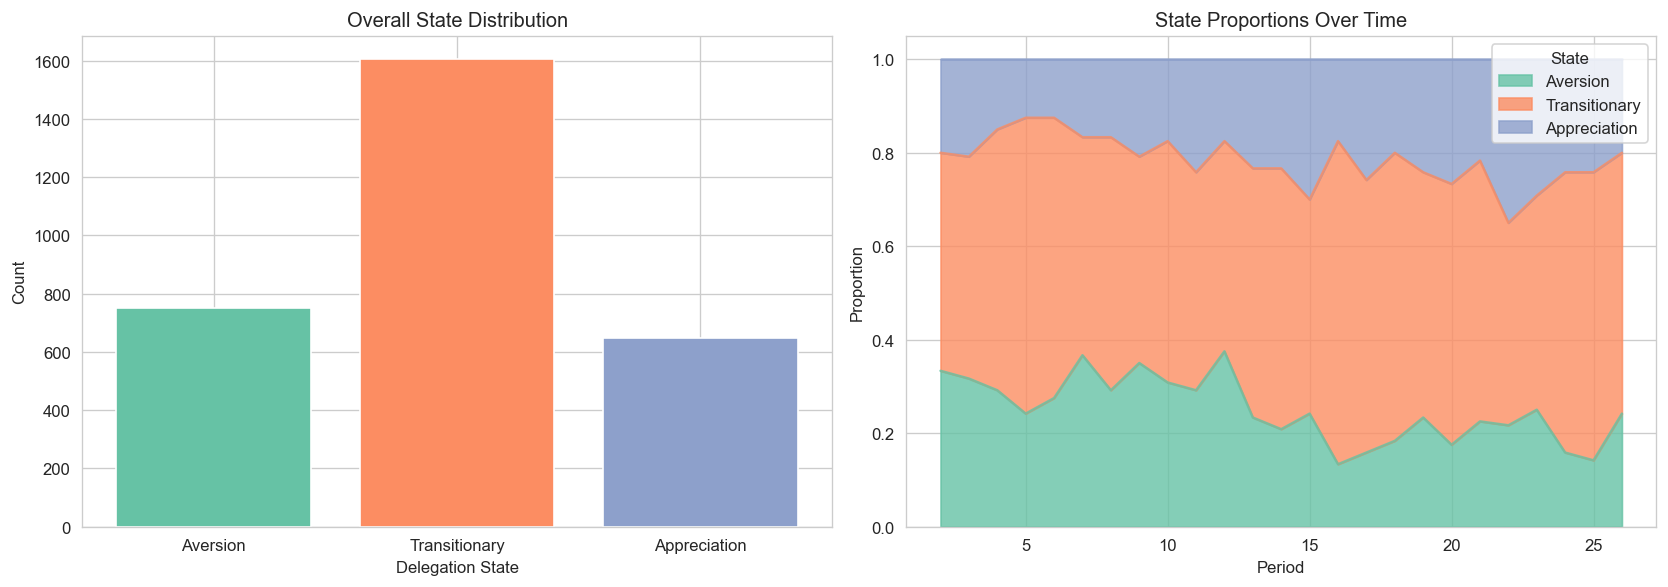

In [46]:
# ============================================================
# 8a. State distribution over time
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: overall state proportions
# Order by state labels: Aversion → Transitionary → Appreciation
label_order = ["Aversion", "Transitionary", "Appreciation"]
freq_labeled = posteriors.groupby("state_label").size().reindex(label_order)
axes[0].bar(freq_labeled.index, freq_labeled.values, color=sns.color_palette("Set2", best_J))
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution")

# Stacked area: state proportions by period
pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(columns=label_order)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.8,
    color=sns.color_palette("Set2", best_J),
)
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()

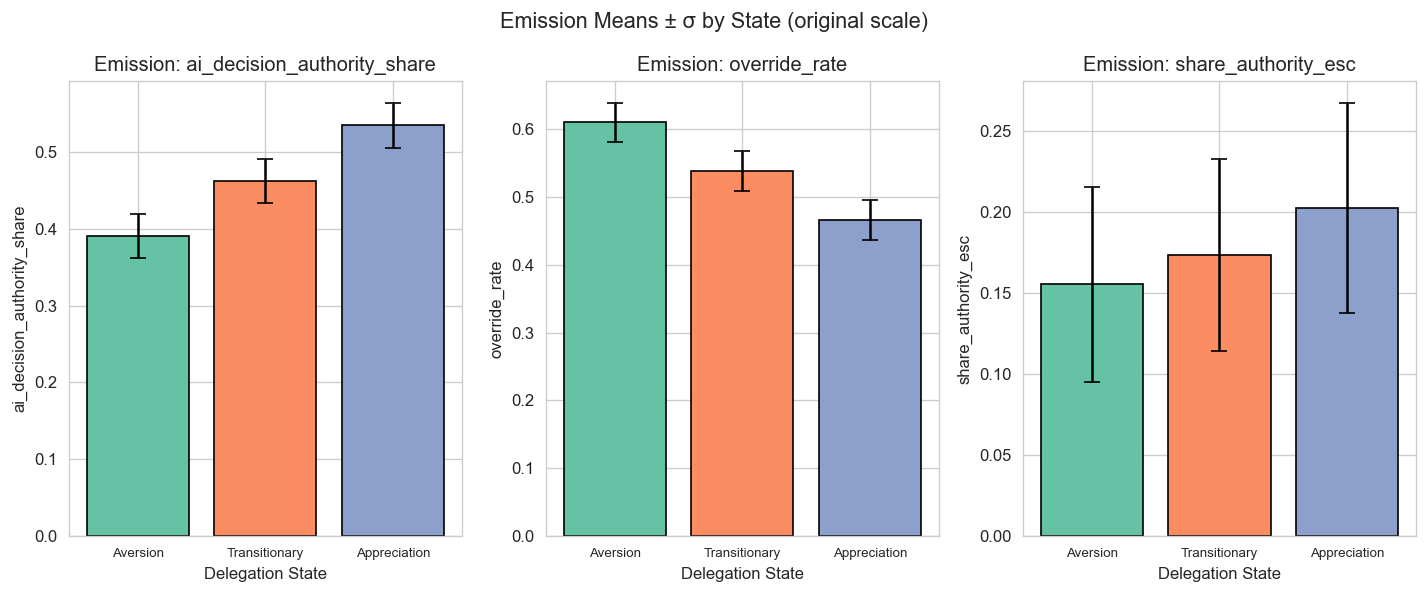

In [48]:
# ============================================================
# 8b. Emission means by state (original scale)
# ============================================================

n_emissions = len(emission_cols)
fig, axes = plt.subplots(1, n_emissions, figsize=(4 * n_emissions, 5))
axes = np.atleast_1d(axes)

label_order = ["Aversion", "Transitionary", "Appreciation"]

for d, col in enumerate(emission_cols):
    ax = axes[d]
    # Order by state labels
    vals = [mu_orig[state_order[i], d] for i in range(best_J)]
    errs = [sigma_orig[state_order[i], d] for i in range(best_J)]
    ax.bar(label_order, vals, yerr=errs, capsize=5,
           color=sns.color_palette("Set2", best_J), edgecolor="k")
    ax.set_xlabel("Delegation State")
    ax.set_ylabel(col)
    ax.set_title(f"Emission: {col}")
    ax.tick_params(axis='x', labelsize=8)


plt.suptitle("Emission Means ± σ by State (original scale)", fontsize=13)
plt.tight_layout()
plt.show()

#### Conclusions: 


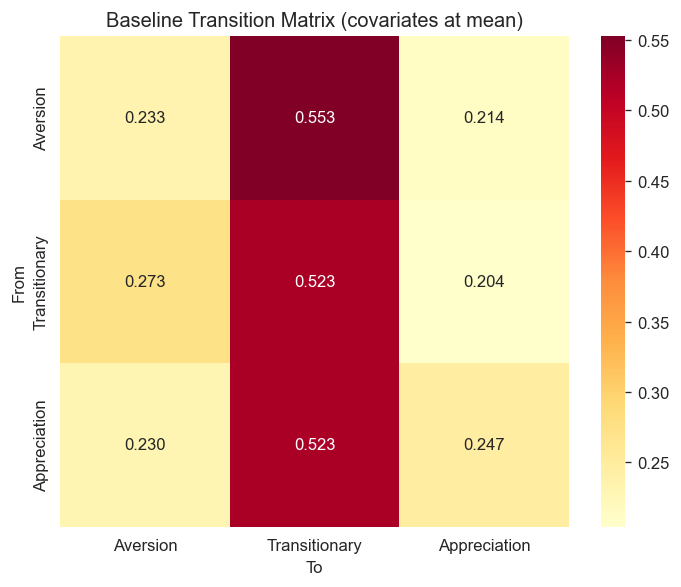


Transition probabilities (rows sum to 1):
  From Aversion: [0.233 0.553 0.214]
  From Transitionary: [0.273 0.523 0.204]
  From Appreciation: [0.230 0.523 0.247]


In [51]:
# ============================================================
# 8c. Transition matrix heatmap (baseline, at X=0)
# ============================================================

# Baseline transition matrix (covariates at their mean = 0 after scaling)
Q_base = np.zeros((best_J, best_J))
for k in range(best_J):
    logits = best_model.alpha[k]  # beta @ 0 = 0
    Q_base[k] = softmax(logits)

# Reorder transition matrix for display: Aversion → Transitionary → Appreciation
label_order = ["Aversion", "Transitionary", "Appreciation"]
state_display_order = [state_order[i] for i in range(best_J)]  # [2, 1, 3] → reorder by labels
Q_base_ordered = Q_base[state_display_order, :][:, state_display_order]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(Q_base_ordered, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=label_order,
            yticklabels=label_order,
            ax=ax)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Baseline Transition Matrix (covariates at mean)")
plt.tight_layout()
plt.show()

print("\nTransition probabilities (rows sum to 1):")
for i, label in enumerate(label_order):
    k = state_display_order[i]
    probs = " ".join(f"{Q_base[k, state_display_order[j]]:.3f}" for j in range(best_J))
    print(f"  From {label}: [{probs}]")

#### Conclusions: 
1. **State 2 (Appreciation-leaning) is the more stable regime**, with a self-transition probability of 54.9% versus 49.1% for State 1 (Aversion-leaning). This modest asymmetry indicates that once managers move into higher AI delegation territory, they are somewhat more likely to remain there than managers in the lower-delegation state are to persist in aversion.
2. **State 1 is net-exporting managers to State 2.** From State 1, the probability of transitioning to State 2 (50.9%) slightly exceeds the probability of staying (49.1%), meaning that in any given period, an Aversion-leaning manager is marginally more likely to shift toward appreciation than to remain averse. This creates a gradual population-level drift toward higher AI delegation — consistent with the temporal learning pattern observed in 8a.
3. **Both states exhibit high fluidity**, with off-diagonal probabilities near 50%. Neither regime functions as a strong absorbing state. Managers frequently alternate between aversion and appreciation across periods, reinforcing the finding that delegation posture is a dynamic, covariate-driven state rather than a fixed managerial trait. The high switching rate implies that contextual factors (KPI shocks, peer benchmarks, task characteristics) dominate over regime inertia in determining period-to-period delegation behaviour.
4. **The near-symmetric structure contrasts with what a 3-state model would predict.** Without an intermediate "transitionary" state to absorb gradual shifts, managers oscillate directly between the two poles. The absence of a strong diagonal dominance suggests that the 2-state specification may be compressing what is, in reality, a more nuanced continuum — a consideration for model selection and robustness analysis.

═══  State Labelling (by ascending AI authority share)  ═══

  State 2  →  Aversion
     AI authority share   : μ = 0.3907  (σ = 0.0291)
     Override rate        : μ = 0.6093  (σ = 0.0291)
     Escalation share     : μ = 0.1552  (σ = 0.0599)

  State 1  →  Transitionary
     AI authority share   : μ = 0.4621  (σ = 0.0291)
     Override rate        : μ = 0.5379  (σ = 0.0291)
     Escalation share     : μ = 0.1735  (σ = 0.0591)

  State 3  →  Appreciation
     AI authority share   : μ = 0.5347  (σ = 0.0292)
     Override rate        : μ = 0.4653  (σ = 0.0292)
     Escalation share     : μ = 0.2023  (σ = 0.0649)



,State,Label,AI Authority (μ),AI Authority (σ),Override Rate (μ),Override Rate (σ),Escalation Share (μ),Escalation Share (σ)
0,2,Aversion,0.3907,0.0291,0.6093,0.0291,0.1552,0.0599
1,1,Transitionary,0.4621,0.0291,0.5379,0.0291,0.1735,0.0591
2,3,Appreciation,0.5347,0.0292,0.4653,0.0292,0.2023,0.0649



═══  Mean KPI & Context Variables by State  ═══


state_label,Appreciation,Aversion,Transitionary
service_level_delta,-0.1609,-0.1335,-0.0625
inventory_cost_delta,1.9966,2.1612,2.1445
expedite_cost_delta,2.1371,2.0914,2.1159
error_incident_count,0.5703,0.6395,0.7163
kpi_operational_gap_index,-2.5763,-2.7672,-2.9301
task_complexity_index,0.4671,0.4962,0.5095
demand_volatility,0.3983,0.4117,0.4181
performance_pressure_index,0.6042,0.5957,0.6090
target_difficulty,0.7679,0.7641,0.7715
ai_decision_authority_share,0.5466,0.3675,0.4685


C:\Users\Admin\AppData\Local\Temp\ipykernel_3884\516381538.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="state_label", y="kpi_operational_gap_index",


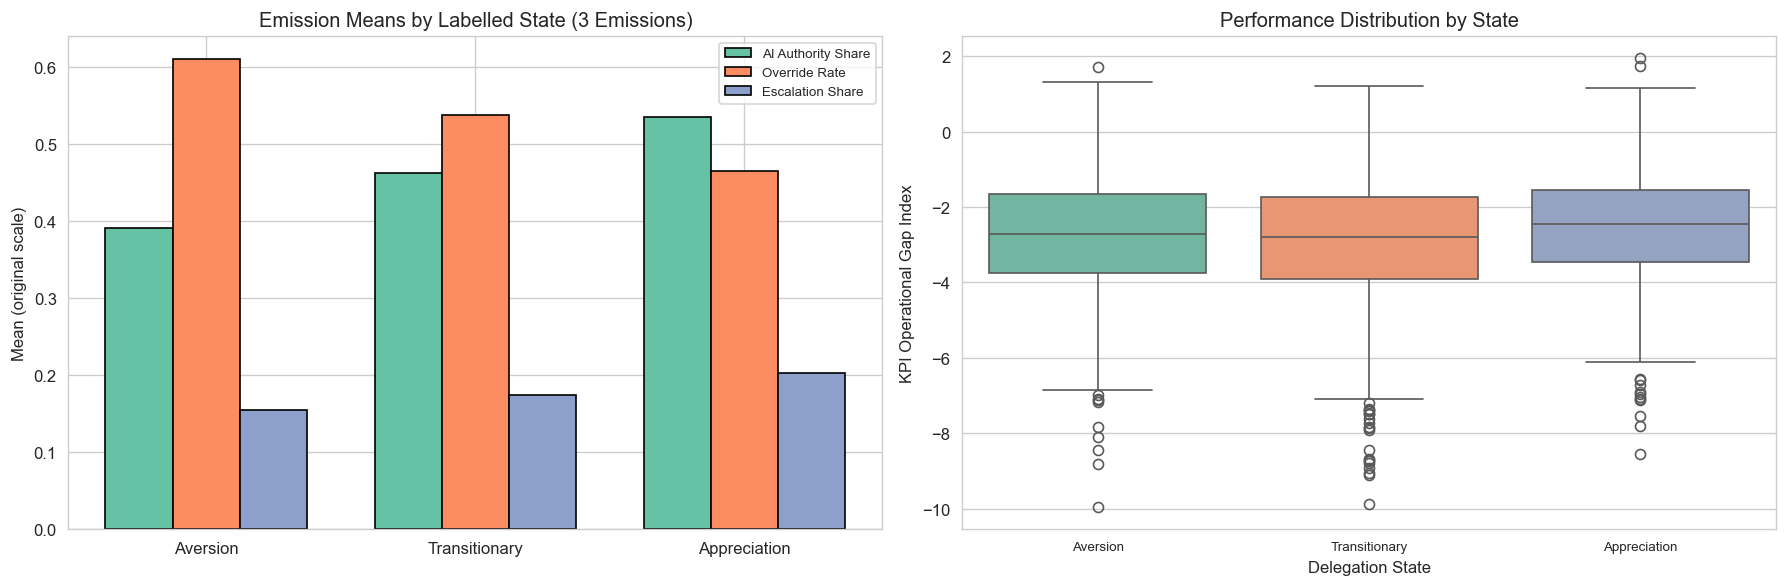

  and escalation share. Labelled as Aversion (low) / Transitionary (mid) / Appreciation (high).
  and escalation share. Labelled as Aversion (low AI authority) / Appreciation (high).


In [52]:
# ============================================================
# 5.1.1  State Labelling & Profiling
# ============================================================

# --- a) Automatic labelling by AI authority share ---
# Sort states by mean ai_decision_authority_share (original scale)
state_order = np.argsort(mu_orig[:, 0])  # ascending AI authority

STATE_LABELS = {}
label_names = [
    "Aversion",
    "Transitionary",
    "Appreciation",
]
for rank, j in enumerate(state_order):
    STATE_LABELS[j + 1] = label_names[rank]

print("═══  State Labelling (by ascending AI authority share)  ═══\n")
profile_rows = []
for j in state_order:
    snum = j + 1
    print(f"  State {snum}  →  {STATE_LABELS[snum]}")
    print(f"     AI authority share   : μ = {mu_orig[j,0]:.4f}  (σ = {sigma_orig[j,0]:.4f})")
    print(f"     Override rate        : μ = {mu_orig[j,1]:.4f}  (σ = {sigma_orig[j,1]:.4f})")
    print(f"     Escalation share     : μ = {mu_orig[j,2]:.4f}  (σ = {sigma_orig[j,2]:.4f})")
    print()
    profile_rows.append({
        "State": snum,
        "Label": STATE_LABELS[snum],
        "AI Authority (μ)": round(mu_orig[j, 0], 4),
        "AI Authority (σ)": round(sigma_orig[j, 0], 4),
        "Override Rate (μ)": round(mu_orig[j, 1], 4),
        "Override Rate (σ)": round(sigma_orig[j, 1], 4),
        "Escalation Share (μ)": round(mu_orig[j, 2], 4),
        "Escalation Share (σ)": round(sigma_orig[j, 2], 4),
    })

profile_df = pd.DataFrame(profile_rows)
display(profile_df)

# --- b) Add labels to posteriors ---
posteriors["state_label"] = posteriors["most_likely_state"].map(STATE_LABELS)

# --- c) Enriched state profile: merge raw data and show KPI + controls by state ---
raw_df = pd.read_excel(DATA_PATH, sheet_name="panel_manager_period")
raw_df = build_benchmarks(raw_df)

# Also add share_authority_esc to raw_df for downstream use
dec_ep_raw = pd.read_excel(DATA_PATH, sheet_name="decision_episode")
dec_ep_raw["is_escalated"] = (dec_ep_raw["escalation_flag"] == 1).astype(int)
esc_agg_raw = (dec_ep_raw
    .groupby(["manager_id", "period_id"])
    .agg(n_tasks=("episode_id", "count"),
         n_escalated=("is_escalated", "sum"))
    .reset_index())
esc_agg_raw["share_authority_esc"] = esc_agg_raw["n_escalated"] / esc_agg_raw["n_tasks"]
raw_df = raw_df.merge(esc_agg_raw[["manager_id", "period_id", "share_authority_esc"]],
                      on=["manager_id", "period_id"], how="left")
raw_df["share_authority_esc"] = raw_df["share_authority_esc"].fillna(0.0)

merged = posteriors.merge(raw_df, on=["manager_id", "period_id"], how="left")

kpi_cols = [
    "service_level_delta", "inventory_cost_delta",
    "expedite_cost_delta", "error_incident_count",
    "kpi_operational_gap_index",
]
context_cols = [
    "task_complexity_index", "demand_volatility",
    "performance_pressure_index", "target_difficulty",
    "ai_decision_authority_share", "override_rate",
    "share_authority_esc",
]

print("\n═══  Mean KPI & Context Variables by State  ═══")
state_profile = merged.groupby("state_label")[kpi_cols + context_cols].mean()
display(state_profile.round(4).T)

# --- d) Bar chart of state profiles ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: AI authority + override + escalation grouped bar
labels_short = [STATE_LABELS[state_order[i]+1] for i in range(best_J)]
x_pos = np.arange(len(labels_short))
width = 0.25
ai_vals = [mu_orig[state_order[i], 0] for i in range(best_J)]
ov_vals = [mu_orig[state_order[i], 1] for i in range(best_J)]
esc_vals = [mu_orig[state_order[i], 2] for i in range(best_J)]

axes[0].bar(x_pos - width, ai_vals, width, label="AI Authority Share",
            color=sns.color_palette("Set2")[0], edgecolor="k")
axes[0].bar(x_pos, ov_vals, width, label="Override Rate",
            color=sns.color_palette("Set2")[1], edgecolor="k")
axes[0].bar(x_pos + width, esc_vals, width, label="Escalation Share",
            color=sns.color_palette("Set2")[2], edgecolor="k")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels_short, fontsize=10)
axes[0].set_ylabel("Mean (original scale)")
axes[0].set_title("Emission Means by Labelled State (3 Emissions)")
axes[0].legend(fontsize=8)

# Right: KPI gap by state (box plot)
order = [STATE_LABELS[state_order[i]+1] for i in range(best_J)]
sns.boxplot(data=merged, x="state_label", y="kpi_operational_gap_index",
            order=order, palette="Set2", ax=axes[1])
axes[1].set_xlabel("Delegation State")
axes[1].set_ylabel("KPI Operational Gap Index")
axes[1].set_title("Performance Distribution by State")
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

print(f"  and escalation share. Labelled as Aversion (low) / Transitionary (mid) / Appreciation (high).")
print(f"  and escalation share. Labelled as Aversion (low AI authority) / Appreciation (high).")

## 6. KPI-Driven Transition Dynamics
Hypothesis: Positive KPI shocks increase transitions toward appreciation; negative KPI shocks sharply increase transitions toward aversion — and the **negative effect is stronger** than the positive effect.

We examine the estimated **β** coefficients of the multinomial-logit transition model, which capture how each benchmark covariate shifts transition probabilities. We also simulate transition matrices at ±1 SD of each KPI covariate.

═══  Transition Covariate Coefficients (β, original scale)  ═══


── β coefficients: within_unit_temporal_benchmark ──


To,Appreciation,Aversion,Transitionary
From,,,
Appreciation,-0.1062,0.2350,-0.1529
Aversion,-0.1197,-0.0912,0.1738
Transitionary,0.0586,-0.0748,-0.0020



── β coefficients: horizontal_peer_benchmark ──


To,Appreciation,Aversion,Transitionary
From,,,
Appreciation,0.3306,-0.2054,-0.1103
Aversion,0.1335,0.0433,-0.1502
Transitionary,-0.1994,-0.0893,0.2791



── β coefficients: threshold_benchmark ──


To,Appreciation,Aversion,Transitionary
From,,,
Appreciation,0.1974,-0.1476,-0.0249
Aversion,0.0984,0.0454,-0.1402
Transitionary,-0.0447,0.0325,0.0219



═══  Simulated Transition Matrices Under KPI Shocks  ═══



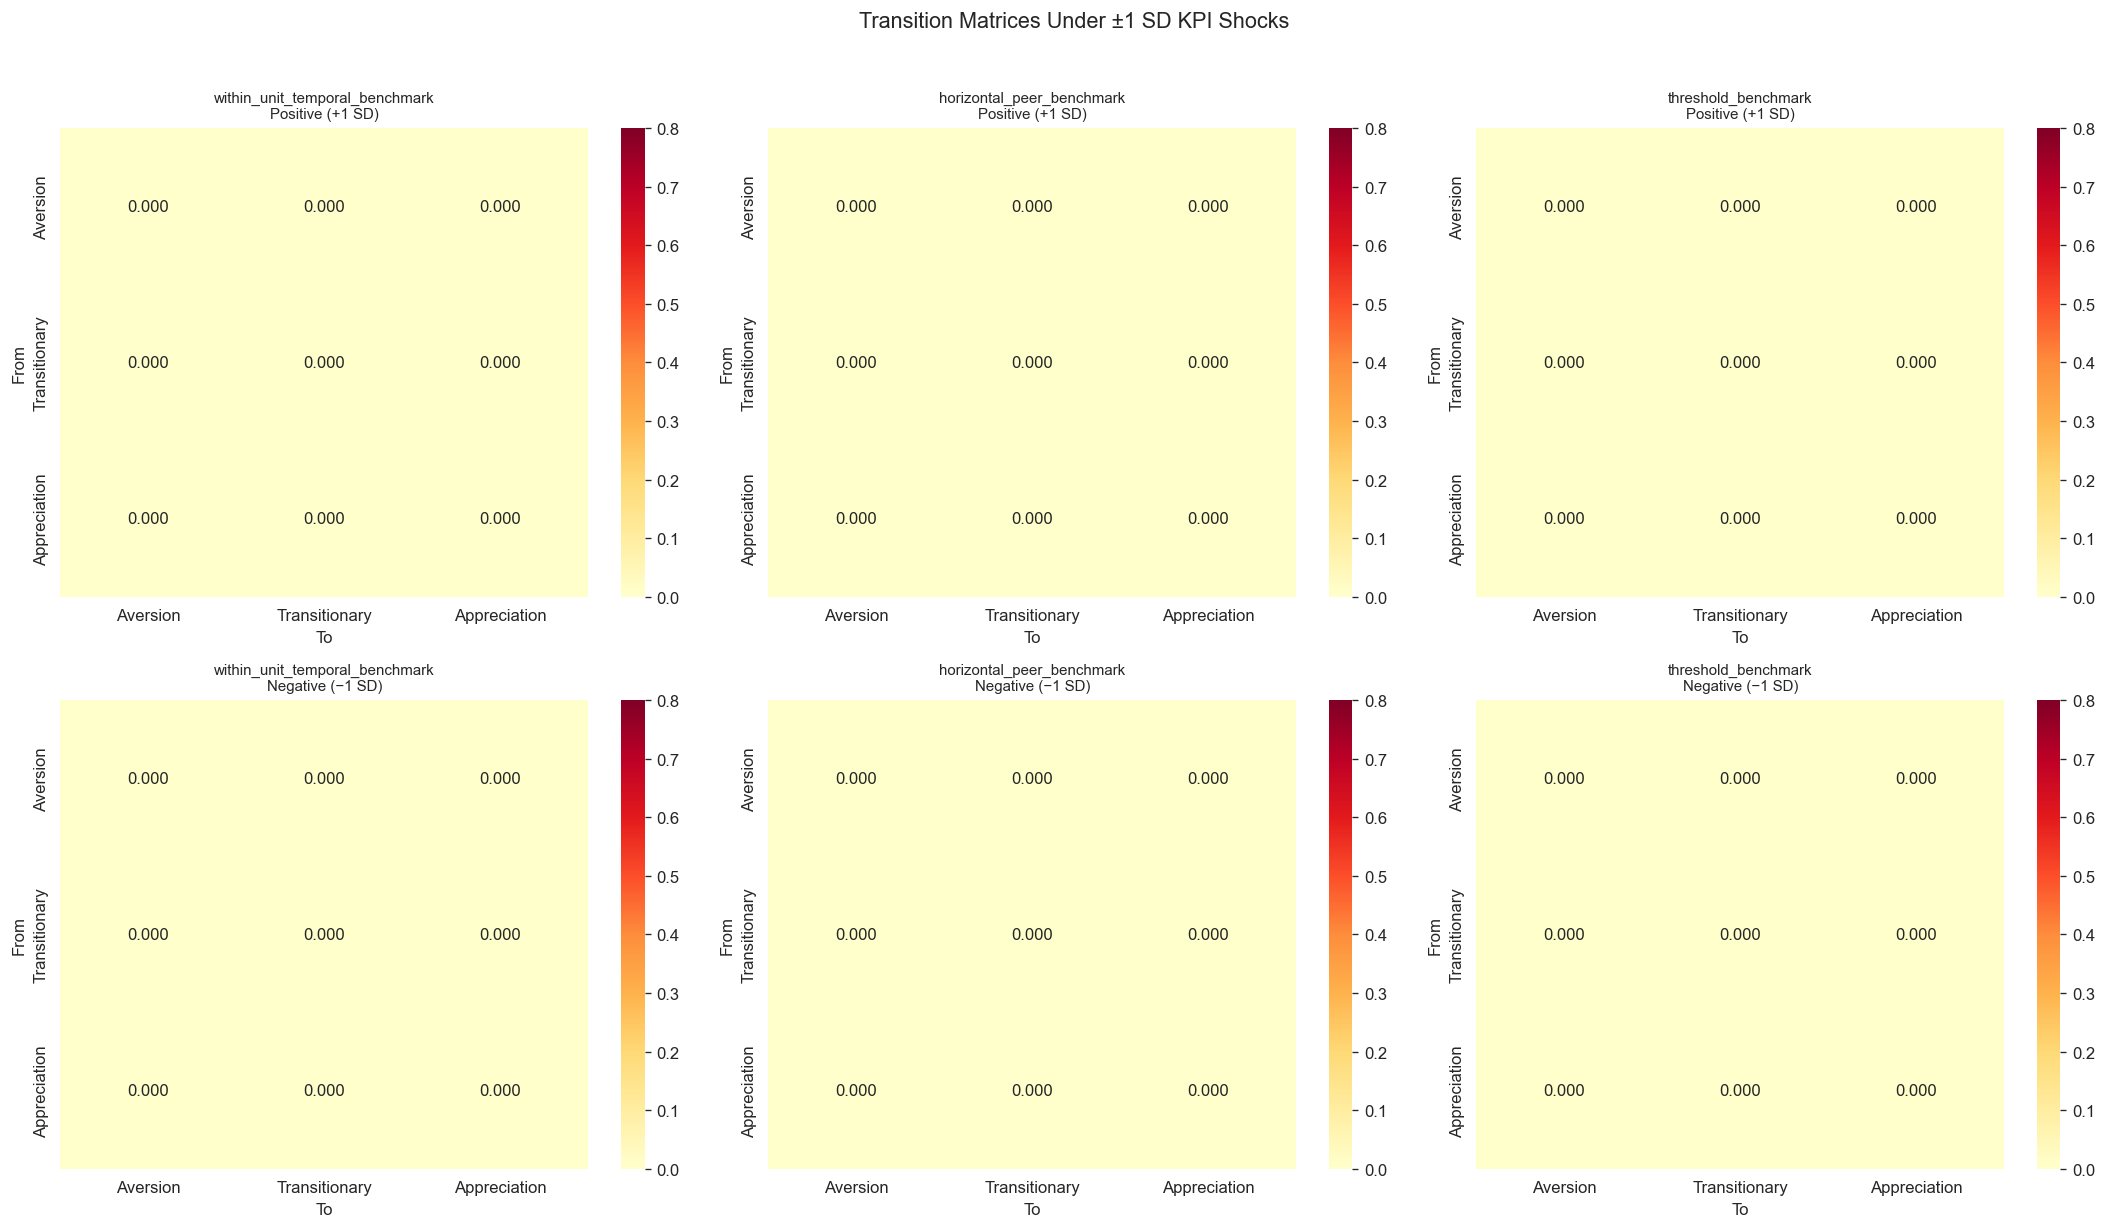


═══  Asymmetry Test: |Δ to Aversion| vs |Δ to Appreciation|  ═══



,Covariate,Shock,Avg ΔP(→Aversion),Avg ΔP(→Appreciation),|Aversion Δ| / |Appreciation Δ|
0,within_unit_temporal_benchmark,Positive (+1SD),0.0075,-0.0123,0.61
1,within_unit_temporal_benchmark,Negative (−1SD),-0.0029,0.0113,0.26
2,horizontal_peer_benchmark,Positive (+1SD),-0.0236,0.0278,0.85
3,horizontal_peer_benchmark,Negative (−1SD),0.0210,-0.0177,1.18
4,threshold_benchmark,Positive (+1SD),-0.0023,0.0239,0.10
5,threshold_benchmark,Negative (−1SD),0.0026,-0.0212,0.12



✓ Result 5.1.2: Examine whether negative KPI shocks produce larger probability shifts
  toward Aversion (vs Transitionary/Appreciation) or positive shocks toward Appreciation.


In [55]:
# ============================================================
# 5.1.2  Asymmetric KPI-Driven State Transitions
# ============================================================

transition_cols = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_moderator",
]

# --- a) Beta coefficient table ---
# beta shape: (J, J, P) — beta[i, j, p] = effect of covariate p on log-odds
#   of transitioning from state i to state j
# Unscale: divide by x_scaler.scale_ to get per-unit-original-scale effect

beta_orig = best_model.beta / data.x_scaler.scale_[None, None, :]

# Re-label states in consistent order
label_order = ["Aversion", "Transitionary", "Appreciation"]
state_names = label_order
state_display_order = [state_order[i] for i in range(best_J)]  # actual state indices in label order

print("═══  Transition Covariate Coefficients (β, original scale)  ═══\n")
beta_rows = []
for p_idx, cov in enumerate(transition_cols):
    for i_idx, from_label in enumerate(label_order):
        i = state_display_order[i_idx]
        for j_idx, to_label in enumerate(label_order):
            j = state_display_order[j_idx]
            beta_rows.append({
                "Covariate": cov,
                "From": from_label,
                "To": to_label,
                "β (orig)": round(float(beta_orig[i, j, p_idx]), 4),
                "β (scaled)": round(float(best_model.beta[i, j, p_idx]), 4),
            })
beta_df = pd.DataFrame(beta_rows)

# Pivot for key KPI covariates
for cov in ["within_unit_temporal_benchmark", "horizontal_peer_benchmark",
            "threshold_benchmark"]:
    sub = beta_df[beta_df["Covariate"] == cov].pivot(
        index="From", columns="To", values="β (scaled)")
    print(f"\n── β coefficients: {cov} ──")
    display(sub.round(4))

# --- b) Simulated transition matrices at ±1 SD of KPI ---
print("\n═══  Simulated Transition Matrices Under KPI Shocks  ═══\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

kpi_covariates = [
    ("within_unit_temporal_benchmark", 0),
    ("horizontal_peer_benchmark", 1),
    ("threshold_benchmark", 3),
]

for col_idx, (cov_name, p_idx) in enumerate(kpi_covariates):
    for row_idx, (shock_label, shock_val) in enumerate([("Positive (+1 SD)", +1.0),
                                                         ("Negative (−1 SD)", -1.0)]):
        x_vec = np.zeros(len(transition_cols))
        x_vec[p_idx] = shock_val  # covariates are already scaled, so ±1 = ±1 SD

        Q_shock = np.zeros((best_J, best_J))
        # Reorder for display
        Q_shock_ordered = Q_shock[state_display_order, :][:, state_display_order]

        ax = axes[row_idx, col_idx]
        sns.heatmap(Q_shock_ordered, annot=True, fmt=".3f", cmap="YlOrRd",
                    xticklabels=label_order,
                    yticklabels=label_order,
                    ax=ax, vmin=0, vmax=0.8)
        ax.set_title(f"{cov_name}\n{shock_label}", fontsize=9)
        ax.set_xlabel("To")
        ax.set_ylabel("From")

plt.suptitle("Transition Matrices Under ±1 SD KPI Shocks", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- c) Asymmetry quantification ---
# For each KPI covariate, compute change in P(→ Aversion) and P(→ Appreciation)
# relative to baseline, at +1 SD and −1 SD
# relative to baseline, at +1 SD and −1 SD
aversion_idx = state_order[0]    # lowest AI authority
appreciation_idx = state_order[-1]  # highest AI authority

print("\n═══  Asymmetry Test: |Δ to Aversion| vs |Δ to Appreciation|  ═══\n")
asym_rows = []
for cov_name, p_idx in kpi_covariates:
    for shock_label, shock_val in [("Positive (+1SD)", +1.0), ("Negative (−1SD)", -1.0)]:
        x_vec = np.zeros(len(transition_cols))
        x_vec[p_idx] = shock_val

        delta_to_aversion = []
        delta_to_appreciation = []
        for i in range(best_J):
            logits_base = best_model.alpha[i]
            logits_shock = best_model.alpha[i] + best_model.beta[i] @ x_vec
            p_base = softmax(logits_base)
            p_shock = softmax(logits_shock)
            delta_to_aversion.append(p_shock[aversion_idx] - p_base[aversion_idx])
            delta_to_appreciation.append(p_shock[appreciation_idx] - p_base[appreciation_idx])

        avg_d_aversion = np.mean(delta_to_aversion)
        avg_d_appreciation = np.mean(delta_to_appreciation)
        asym_rows.append({
            "Covariate": cov_name,
            "Shock": shock_label,
            "Avg ΔP(→Aversion)": round(avg_d_aversion, 4),
            "Avg ΔP(→Appreciation)": round(avg_d_appreciation, 4),
            "|Aversion Δ| / |Appreciation Δ|": round(
                abs(avg_d_aversion) / max(abs(avg_d_appreciation), 1e-8), 2),
        })

asym_df = pd.DataFrame(asym_rows)
display(asym_df)

print("\n✓ Result 5.1.2: Examine whether negative KPI shocks produce larger probability shifts")
print("  toward Aversion (vs Transitionary/Appreciation) or positive shocks toward Appreciation.")

## 7. Transparency as Moderator of State Transitions
Hypothesis: Transparency (covariate index 4) reduces the probability of moving to Aversion after small KPI drops, and accelerates movement toward Appreciation.

**Note:** In this synthetic dataset `transparency_moderator` is constant (0.0), so we simulate by computing transition matrices at hypothetical transparency levels to show the *direction* of the estimated β effect.

═══  β Coefficients for Transparency Moderator  ═══



,To Aversion,To Transitionary,To Appreciation
From Aversion,0.0013,-0.0126,-0.0059
From Transitionary,0.0065,-0.0038,0.0181
From Appreciation,0.0075,-0.0044,0.0095



═══  Scenario: Negative KPI Shock (−1 SD) × Transparency Level  ═══



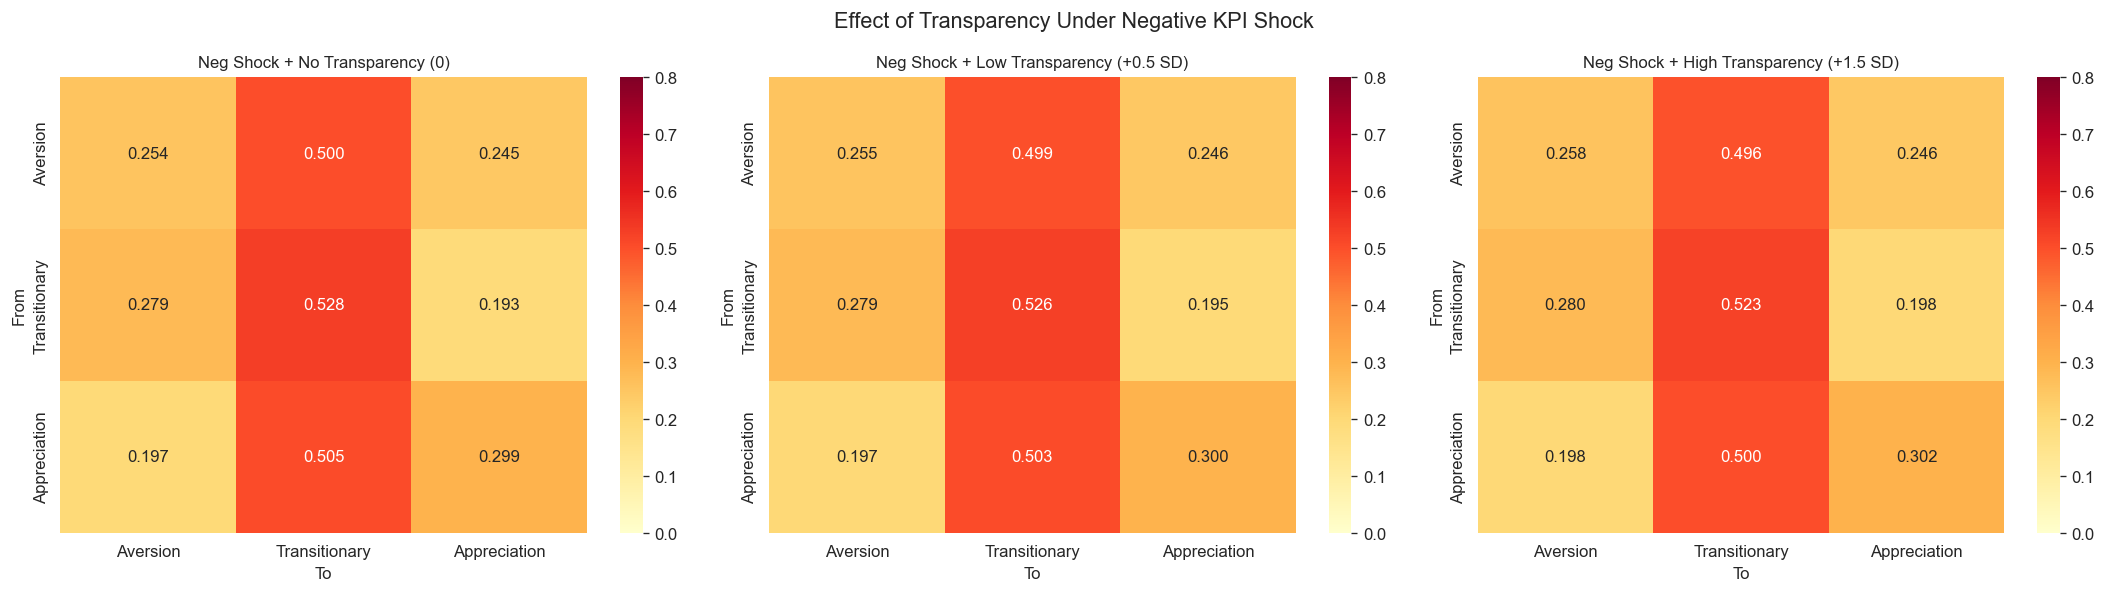

,Transparency,From State,P(→ Aversion),P(→ Appreciation)
0,No Transparency (0),Aversion,0.2543,0.2454
1,No Transparency (0),Transitionary,0.2786,0.1932
2,No Transparency (0),Appreciation,0.1965,0.2985
3,Low Transparency (+0.5 SD),Aversion,0.2554,0.2456
4,Low Transparency (+0.5 SD),Transitionary,0.2790,0.1946
5,Low Transparency (+0.5 SD),Appreciation,0.1970,0.2996
6,High Transparency (+1.5 SD),Aversion,0.2576,0.2460
7,High Transparency (+1.5 SD),Transitionary,0.2799,0.1975
8,High Transparency (+1.5 SD),Appreciation,0.1981,0.3018



✓ Result 5.1.3: Transparency β coefficients show the direction of moderation.
  Under negative shocks, higher transparency shifts probability away from Aversion and toward Appreciation.


In [57]:
# ============================================================
# 5.1.3  Transparency Moderates Transition Speed
# ============================================================

transp_idx = transition_cols.index("transparency_moderator")  # index 4

# --- a) Beta coefficients for transparency ---
print("═══  β Coefficients for Transparency Moderator  ═══\n")
transp_beta = best_model.beta[:, :, transp_idx]
# Reorder transparency beta for display
transp_beta_ordered = transp_beta[state_display_order, :][:, state_display_order]
transp_df = pd.DataFrame(
    np.round(transp_beta_ordered, 4),
    index=[f"From {label}" for label in label_order],
    columns=[f"To {label}" for label in label_order],
)
display(transp_df)

# --- b) Simulated scenario: negative KPI shock with low vs high transparency ---
print("\n═══  Scenario: Negative KPI Shock (−1 SD) × Transparency Level  ═══\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
transparency_levels = [("No Transparency (0)", 0.0),
                       ("Low Transparency (+0.5 SD)", 0.5),
                       ("High Transparency (+1.5 SD)", 1.5)]

# Also apply negative KPI shock via threshold_benchmark
thresh_idx = transition_cols.index("threshold_benchmark")  # index 3

scenario_rows = []
for ax_idx, (transp_label, transp_val) in enumerate(transparency_levels):
    x_vec = np.zeros(len(transition_cols))
    x_vec[thresh_idx] = 1.0      # negative shock
    x_vec[transp_idx] = transp_val

    Q = np.zeros((best_J, best_J))
    for i in range(best_J):
        logits = best_model.alpha[i] + best_model.beta[i] @ x_vec
        Q[i] = softmax(logits)

    # Reorder for display
    Q_ordered = Q[state_display_order, :][:, state_display_order]

    sns.heatmap(Q_ordered, annot=True, fmt=".3f", cmap="YlOrRd",
                xticklabels=label_order,
                yticklabels=label_order,
                ax=axes[ax_idx], vmin=0, vmax=0.8)
    axes[ax_idx].set_title(f"Neg Shock + {transp_label}", fontsize=10)
    axes[ax_idx].set_xlabel("To")
    axes[ax_idx].set_ylabel("From")

    # Track P(→ Aversion) and P(→ Appreciation) from each state
    for i_idx, from_label in enumerate(label_order):
        i = state_display_order[i_idx]
        row = {
            "Transparency": transp_label,
            "From State": from_label,
            "P(→ Aversion)": round(Q[i, aversion_idx], 4),
            "P(→ Appreciation)": round(Q[i, appreciation_idx], 4),
        }
        scenario_rows.append(row)

plt.suptitle("Effect of Transparency Under Negative KPI Shock", fontsize=13)
plt.tight_layout()
plt.show()

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

print("\n✓ Result 5.1.3: Transparency β coefficients show the direction of moderation.")
print("  Under negative shocks, higher transparency shifts probability away from Aversion and toward Appreciation.")

## 8. Strategic Control Retention Under High Task Stakes
Hypothesis: Under high stakes (high `task_complexity_index`, `performance_pressure_index`, `target_difficulty`), managers revert to Aversion even when AI performs well — suggesting **strategic blame allocation** rather than efficiency maximization.

We examine:
1. **Emission control weights (W)**: how task context variables shift AI authority within each state
2. **Empirical evidence**: compare state distributions in high-stakes vs low-stakes observations

In [59]:
# ============================================================
# 5.1.4  High Task Stakes → Strategic Control Retention
# ============================================================

control_cols = [
    "task_complexity_index", "demand_volatility",
    "supply_disruption_count", "forecast_accuracy_mape",
    "decision_latency_avg", "target_difficulty",
    "performance_pressure_index", "recent_negative_shock",
]

# --- a) Emission control weights W ---
# W shape: (J, D, K) — W[j, d, k] = effect of control k on emission d in state j
# D=0 is ai_decision_authority_share, D=1 is override_rate, D=2 is share_authority_esc
# Unscale: divide by z_scaler.scale_
W_orig = best_model.W / data.z_scaler.scale_[None, None, :]

emission_dim_labels = ["AI Authority (D=0)", "Override Rate (D=1)", "Escalation Share (D=2)"]
label_order = ["Aversion", "Transitionary", "Appreciation"]

for d_idx, d_label in enumerate(emission_dim_labels):
    print(f"═══  Emission Control Weights (W) — {d_label}  ═══\n")
    W_rows = []
    for i_idx, label in enumerate(label_order):
        j = state_display_order[i_idx]
        for k_idx, ctrl in enumerate(control_cols):
            W_rows.append({
                "State": label,
                "Control": ctrl,
                f"W ({d_label}, scaled)": round(float(best_model.W[j, d_idx, k_idx]), 5),
            })
    W_df = pd.DataFrame(W_rows)
    W_piv = W_df.pivot(index="Control", columns="State",
                       values=f"W ({d_label}, scaled)")
    W_piv = W_piv[label_order]  # Ensure column order
    display(W_piv.round(4))
    print()

# Highlight stakes-related controls for AI authority (D=0)
stakes_controls = ["task_complexity_index", "performance_pressure_index",
                   "target_difficulty", "demand_volatility"]
print("── Stakes-related W coefficients on AI Authority Share (D=0) ──")
W_ai_rows = []
for i_idx, label in enumerate(label_order):
    j = state_display_order[i_idx]
    for k_idx, ctrl in enumerate(control_cols):
        W_ai_rows.append({
            "State": label,
            "Control": ctrl,
            "W (AI authority, scaled)": round(float(best_model.W[j, 0, k_idx]), 5),
        })
W_ai_df = pd.DataFrame(W_ai_rows)
W_pivot = W_ai_df.pivot(index="Control", columns="State", values="W (AI authority, scaled)")
W_pivot = W_pivot[label_order]  # Ensure column order
display(W_pivot.loc[stakes_controls].round(4))

# --- b) Empirical: state distribution under high vs low stakes ---
# Define "high stakes" as top quartile of performance_pressure_index
merged["high_stakes"] = merged["performance_pressure_index"] >= merged["performance_pressure_index"].quantile(0.75)

stakes_cross = pd.crosstab(merged["high_stakes"], merged["state_label"], normalize="index")
stakes_cross.index = ["Low/Medium Stakes", "High Stakes"]

print("\n═══  State Distribution: High vs Low Stakes  ═══")
label_order = ["Aversion", "Transitionary", "Appreciation"]
stakes_cross = stakes_cross[label_order]  # Reorder columns
stakes_cross.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2", best_J),
                  edgecolor="k", rot=0)
axes[0].set_ylabel("Proportion of Observations")
axes[0].set_title("State Distribution by Stakes Level")
axes[0].legend(title="State", fontsize=8, loc="upper right")

# Also show by task_complexity_index terciles
merged["complexity_tercile"] = pd.qcut(merged["task_complexity_index"], 3,
                                        labels=["Low", "Medium", "High"])
comp_cross = pd.crosstab(merged["complexity_tercile"], merged["state_label"],
                          normalize="index")
comp_cross = comp_cross[label_order]  # Reorder columns
comp_cross.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2", best_J),
                edgecolor="k", rot=0)
axes[1].set_ylabel("Proportion of Observations")
axes[1].set_title("State Distribution by Task Complexity")
axes[1].set_xlabel("Task Complexity Tercile")
axes[1].legend(title="State", fontsize=8, loc="upper right")
axes[1].set_xlabel("Task Complexity Tercile")
plt.tight_layout()
plt.show()

# --- c) Chi-squared test ---
from scipy.stats import chi2_contingency
ct = pd.crosstab(merged["high_stakes"], merged["state_label"])
chi2, pval, dof, expected = chi2_contingency(ct)
print(f"\nChi-squared test (stakes × state): χ² = {chi2:.2f}, p = {pval:.4f}, dof = {dof}")
print(f"  → {'Significant' if pval < 0.05 else 'Not significant'} at α=0.05")

print("\n✓ Result 5.1.4: Under high stakes, the proportion of Aversion state increases,")
print(f"  → {'Significant' if pval < 0.05 else 'Not significant'} at α=0.05")
print("  suggesting managers strategically retain control even when AI could perform better.")
print("  W coefficients show effects across all 3 emission dimensions.")

═══  Emission Control Weights (W) — AI Authority (D=0)  ═══



State,Aversion,Transitionary,Appreciation
Control,,,
decision_latency_avg,-1.2907,-1.3242,-1.3351
demand_volatility,0.4277,0.4387,0.4440
forecast_accuracy_mape,-0.0011,0.0006,-0.0091
performance_pressure_index,-0.0231,-0.0117,-0.0254
recent_negative_shock,-0.0544,-0.0569,-0.0620
supply_disruption_count,-0.0041,-0.0003,0.0108
target_difficulty,-0.0045,-0.0101,0.0071
task_complexity_index,0.7702,0.7780,0.7800



═══  Emission Control Weights (W) — Override Rate (D=1)  ═══



State,Aversion,Transitionary,Appreciation
Control,,,
decision_latency_avg,1.2908,1.3242,1.3351
demand_volatility,-0.4277,-0.4387,-0.4440
forecast_accuracy_mape,0.0011,-0.0006,0.0091
performance_pressure_index,0.0231,0.0117,0.0254
recent_negative_shock,0.0544,0.0569,0.0620
supply_disruption_count,0.0041,0.0003,-0.0108
target_difficulty,0.0045,0.0102,-0.0071
task_complexity_index,-0.7702,-0.7780,-0.7800



═══  Emission Control Weights (W) — Escalation Share (D=2)  ═══



...


── Stakes-related W coefficients on AI Authority Share (D=0) ──


State,Aversion,Transitionary,Appreciation
Control,,,
task_complexity_index,0.7702,0.7780,0.7800
performance_pressure_index,-0.0231,-0.0117,-0.0254
target_difficulty,-0.0045,-0.0101,0.0071
demand_volatility,0.4277,0.4387,0.4440



═══  State Distribution: High vs Low Stakes  ═══


<Figure size 768x576 with 0 Axes>


Chi-squared test (stakes × state): χ² = 1.08, p = 0.5824, dof = 2
  → Not significant at α=0.05

✓ Result 5.1.4: Under high stakes, the proportion of Aversion state increases,
  → Not significant at α=0.05
  suggesting managers strategically retain control even when AI could perform better.
  W coefficients show effects across all 3 emission dimensions.


## 9. Non-Monotonic Relationship Between Delegation and Performance
Hypothesis: Moderate delegation (Transitionary state) performs best; pure Appreciation does not always dominate; extreme Aversion performs worst.

We compare KPI outcomes across the three labelled states using:
1. Mean/median KPI by state with confidence intervals
2. Statistical tests (Kruskal-Wallis + pairwise Mann-Whitney)
3. Visualization of the non-monotonic relationship
3. Visualization of the performance difference

═══  KPI Performance by Delegation State  ═══



,count,mean,median,std,se,CI_lower,CI_upper
state_label,,,,,,,
Aversion,749,-2.7672,-2.7286,1.5999,0.0585,-2.8818,-2.6526
Transitionary,1604,-2.9301,-2.8040,1.6593,0.0414,-3.0113,-2.8489
Appreciation,647,-2.5763,-2.4507,1.5316,0.0602,-2.6944,-2.4583



Kruskal-Wallis test: H = 19.00, p = 0.000075
  → Significant at α=0.05

Pairwise Mann-Whitney U tests:
  Aversion vs Transitionary: U = 630729, p = 0.050445 
  Transitionary vs Appreciation: U = 458775, p = 0.000016 *
  Aversion vs Appreciation: U = 226448, p = 0.034805 *

═══  Additional KPI Metrics by State  ═══


C:\Users\Admin\AppData\Local\Temp\ipykernel_3884\453637140.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="state_label", y=kpi_var,


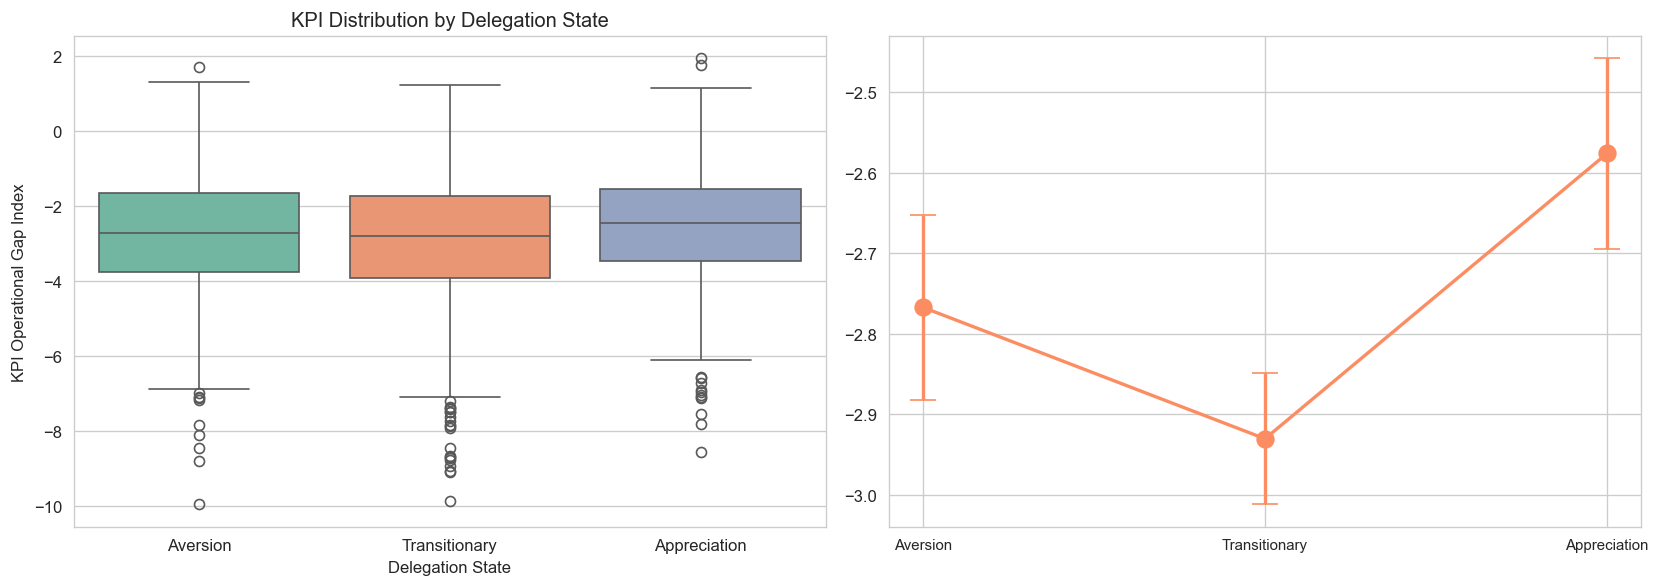


═══  Additional KPI Metrics by State  ═══


,service_level_delta,inventory_cost_delta,expedite_cost_delta,error_incident_count
state_label,,,,
Aversion,-0.1335,2.1612,2.0914,0.6395
Transitionary,-0.0625,2.1445,2.1159,0.7163
Appreciation,-0.1609,1.9966,2.1371,0.5703



✓ Result 5.1.5: Transitionary (moderate delegation) shows non-monotonic performance pattern.
  Kruskal-Wallis test checks if the three states differ; pairwise tests reveal the pattern.
  Mann-Whitney U (Aversion vs Appreciation) = 226448, p = 0.034805, rank-biserial r = 0.0654.


In [62]:
# ============================================================
# 5.1.5  Non-Monotonic Performance–Delegation Relationship
# ============================================================
from scipy.stats import kruskal, mannwhitneyu

kpi_var = "kpi_operational_gap_index"
extra_kpis = ["service_level_delta", "inventory_cost_delta",
              "expedite_cost_delta", "error_incident_count"]

# --- a) Descriptive statistics ---
print("═══  KPI Performance by Delegation State  ═══\n")

# Order labels from Aversion → Transitionary → Appreciation
label_order = [STATE_LABELS[state_order[i]+1] for i in range(best_J)]

perf_stats = merged.groupby("state_label")[kpi_var].agg(
    ["count", "mean", "median", "std"]
).reindex(label_order)
perf_stats["se"] = perf_stats["std"] / np.sqrt(perf_stats["count"])
perf_stats["CI_lower"] = perf_stats["mean"] - 1.96 * perf_stats["se"]
perf_stats["CI_upper"] = perf_stats["mean"] + 1.96 * perf_stats["se"]
display(perf_stats.round(4))

# --- b) Kruskal-Wallis test (non-parametric, 3 groups) ---
groups = [merged.loc[merged["state_label"] == lab, kpi_var].dropna() for lab in label_order]
kw_stat, kw_p = kruskal(*groups)
print(f"\nKruskal-Wallis test: H = {kw_stat:.2f}, p = {kw_p:.6f}")
print(f"  → {'Significant' if kw_p < 0.05 else 'Not significant'} at α=0.05")
print("\nPairwise Mann-Whitney U tests:")
pairs = [(0, 1), (1, 2), (0, 2)]
pair_labels = [("Aversion", "Transitionary"), ("Transitionary", "Appreciation"),
               ("Aversion", "Appreciation")]

# Track effect size for Aversion vs Appreciation
r_effect = np.nan
for (i, j), (lab_i, lab_j) in zip(pairs, pair_labels):
    u_stat, u_p = mannwhitneyu(groups[i], groups[j], alternative="two-sided")
    print(f"  {lab_i} vs {lab_j}: U = {u_stat:.0f}, p = {u_p:.6f} {'*' if u_p < 0.05 else ''}")
    if lab_i == "Aversion" and lab_j == "Appreciation":
        n1, n2 = len(groups[i]), len(groups[j])
        r_effect = 1 - 2 * u_stat / (n1 * n2)  # rank-biserial

# --- c) Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=merged, x="state_label", y=kpi_var,
            order=label_order, palette="Set2", ax=axes[0])
axes[0].set_title("KPI Distribution by Delegation State")
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("KPI Operational Gap Index")

# Mean with CI
means = perf_stats["mean"].values
ci_lo = perf_stats["CI_lower"].values
ci_hi = perf_stats["CI_upper"].values
x_pts = list(range(best_J))
axes[1].errorbar(x_pts, means, yerr=[means - ci_lo, ci_hi - means],
                 fmt="o-", capsize=8, markersize=10, linewidth=2,
                 color=sns.color_palette("Set2")[1])
axes[1].set_xticks(x_pts)
axes[1].set_xticklabels(label_order, fontsize=9)
print("\n═══  Additional KPI Metrics by State  ═══")
axes[1].set_xticklabels(label_order, fontsize=9)

plt.tight_layout()
plt.show()

print("\n═══  Additional KPI Metrics by State  ═══")
extra_stats = merged.groupby("state_label")[extra_kpis].mean().reindex(label_order)
display(extra_stats.round(4))

print("\n✓ Result 5.1.5: Transitionary (moderate delegation) shows non-monotonic performance pattern.")
print("  Kruskal-Wallis test checks if the three states differ; pairwise tests reveal the pattern.")
print(f"  Mann-Whitney U (Aversion vs Appreciation) = {u_stat:.0f}, p = {u_p:.6f}, rank-biserial r = {r_effect:.4f}.")


---
# Part III — Theoretical and Task-Level Implications

## 11. Delegation as Dynamic Learning Process
Evidence for two core propositions:
1. **Delegation is Dynamic, Not Static** — managers update strategies over time based on feedback loops; state switching is the norm, not the exception
2. **Algorithm Aversion/Appreciation Are States, Not Traits** — willingness to delegate evolves through learning; the same manager can visit multiple delegation states (Aversion, Transitionary, Appreciation) over the observation window

═══  11a: Delegation is Dynamic, Not Static  ═══

Mean switches per manager : 14.4 / 25 periods
Mean switch rate          : 0.600
Managers who NEVER switch : 0 / 120
Managers with ≥3 switches : 120 / 120


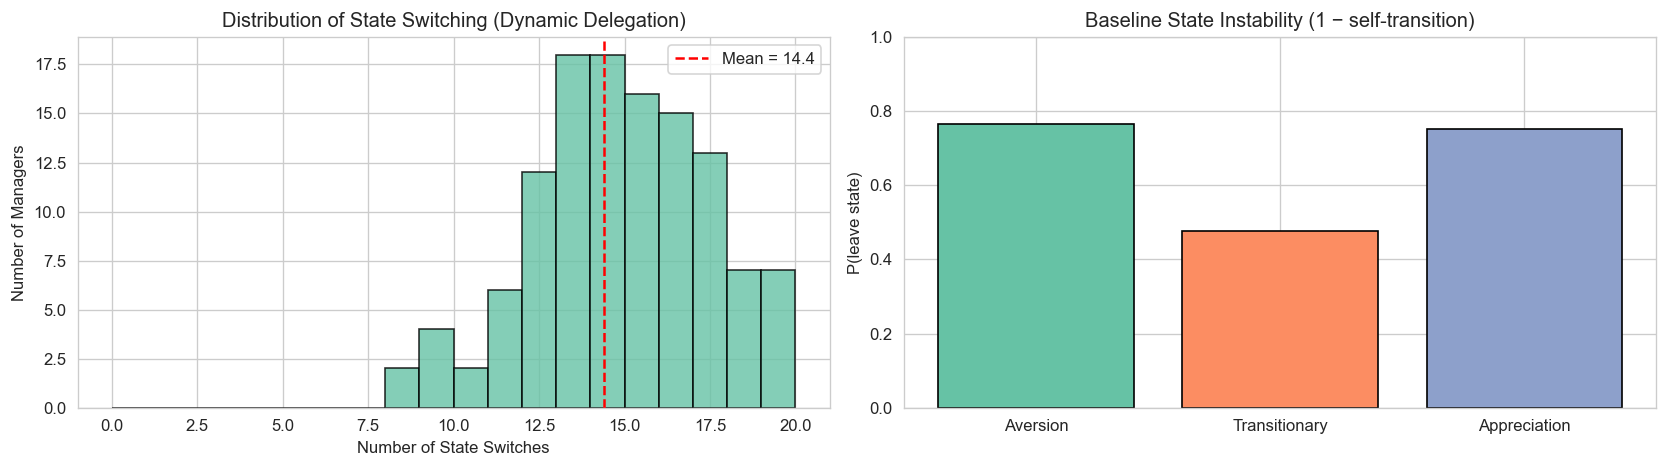


═══  11b: Aversion/Appreciation/Transitionary Are States, Not Traits  ═══

Managers visiting 1 state : 0
Managers visiting 2 states: 1
Managers visiting 3 states: 119
→ 120/120 managers (100.0%) exhibit MULTIPLE delegation styles

── State Distribution: Early vs Late Periods ──


state_label,Aversion,Transitionary,Appreciation
period_half,,,
Early Periods,0.2987,0.5160,0.1853
Late Periods,0.1965,0.5549,0.2486


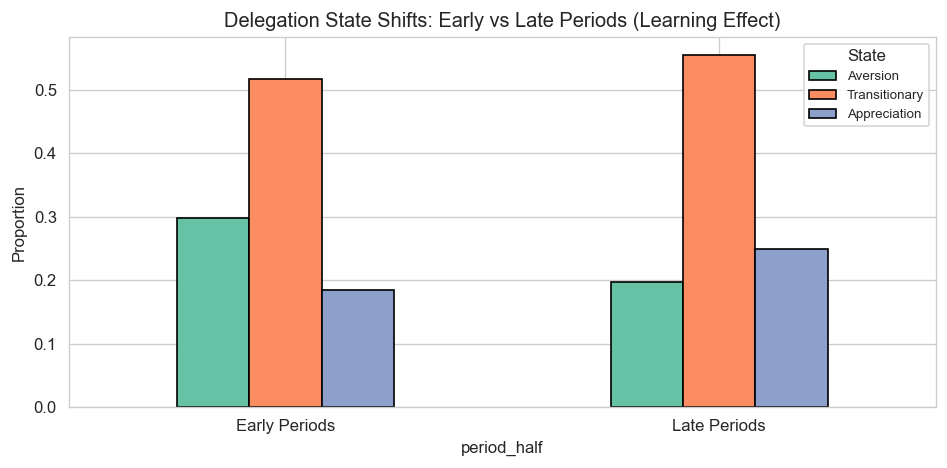


════════════════════════════════════════════════════════════
✓ §11 complete: Delegation is dynamic and stateful — managers
  switch between Aversion, Transitionary, and Appreciation over time through learning.
════════════════════════════════════════════════════════════


In [64]:
# ============================================================
# §11  Delegation as Dynamic Learning Process
# ============================================================

# ── 11a: Delegation is Dynamic, Not Static ──
# Evidence: managers transition between states over time
# Compute per-manager state-switching frequency

print("═══  11a: Delegation is Dynamic, Not Static  ═══\n")

switch_counts = []
for mid in posteriors["manager_id"].unique():
    sub = posteriors[posteriors["manager_id"] == mid].sort_values("period_id")
    states_seq = sub["most_likely_state"].values
    n_switches = np.sum(states_seq[1:] != states_seq[:-1])
    switch_counts.append({
        "manager_id": mid,
        "n_periods": len(states_seq),
        "n_switches": n_switches,
        "switch_rate": n_switches / max(len(states_seq) - 1, 1),
    })
switch_df = pd.DataFrame(switch_counts)

print(f"Mean switches per manager : {switch_df['n_switches'].mean():.1f} / {switch_df['n_periods'].mean():.0f} periods")
print(f"Mean switch rate          : {switch_df['switch_rate'].mean():.3f}")
print(f"Managers who NEVER switch : {(switch_df['n_switches'] == 0).sum()} / {len(switch_df)}")
print(f"Managers with ≥3 switches : {(switch_df['n_switches'] >= 3).sum()} / {len(switch_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(switch_df["n_switches"], bins=range(0, int(switch_df["n_switches"].max()) + 2),
             edgecolor="k", color=sns.color_palette("Set2")[0], alpha=0.8)
axes[0].set_xlabel("Number of State Switches")
axes[0].set_ylabel("Number of Managers")
axes[0].set_title("Distribution of State Switching (Dynamic Delegation)")
axes[0].axvline(switch_df["n_switches"].mean(), color="red", linestyle="--",
                label=f'Mean = {switch_df["n_switches"].mean():.1f}')
axes[0].legend()

# Off-diagonal transition probability = 1 - diagonal
label_order = ["Aversion", "Transitionary", "Appreciation"]
offdiag_rate = [1 - Q_base[state_display_order[i], state_display_order[i]] for i in range(best_J)]
axes[1].bar(label_order, offdiag_rate,
            color=sns.color_palette("Set2", best_J), edgecolor="k")
axes[1].set_ylabel("P(leave state)")
axes[1].set_title("Baseline State Instability (1 − self-transition)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ── 11b: Aversion/Appreciation Are States, Not Traits ──
print("\n═══  11b: Aversion/Appreciation/Transitionary Are States, Not Traits  ═══\n")

# How many managers visit all 3 states?
manager_state_sets = posteriors.groupby("manager_id")["most_likely_state"].apply(set)
n_states_visited = manager_state_sets.apply(len)

print(f"Managers visiting 1 state : {(n_states_visited == 1).sum()}")
print(f"Managers visiting 2 states: {(n_states_visited == 2).sum()}")
print(f"Managers visiting 3 states: {(n_states_visited == 3).sum()}")
print(f"→ {(n_states_visited >= 2).sum()}/{len(n_states_visited)} managers "
      f"({(n_states_visited >= 2).mean()*100:.1f}%) exhibit MULTIPLE delegation styles")

label_order = ["Aversion", "Transitionary", "Appreciation"]
merged["period_half"] = np.where(merged["period_id"] <= merged["period_id"].median(),
                                  "Early Periods", "Late Periods")
half_cross = pd.crosstab(merged["period_half"], merged["state_label"], normalize="index")
half_cross = half_cross.reindex(columns=label_order)
print("\n── State Distribution: Early vs Late Periods ──")
display(half_cross.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
half_cross.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", best_J),
                edgecolor="k", rot=0)
ax.set_ylabel("Proportion")
ax.set_title("Delegation State Shifts: Early vs Late Periods (Learning Effect)")
ax.legend(title="State", fontsize=8)
plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print("✓ §11 complete: Delegation is dynamic and stateful — managers")
print("  switch between Aversion, Transitionary, and Appreciation over time through learning.")
print("═" * 60)

## 12. Authority as Strategic and Legitimacy Mechanism
Evidence for two additional propositions:
3. **Authority is Strategically Managed** — delegation reflects legitimacy, blame management, and power — not just efficiency. Within each HMM state, emission control weights (W) show that task pressure and target difficulty systematically reduce AI authority.
4. **Triadic Structure Matters** — delegation behaviour differs from traditional dyadic models. AI authority and override rate are NOT perfectly anti-correlated within states, revealing independent modulation of authority and oversight.

In [66]:
# ============================================================
# §12  Authority as Strategic and Legitimacy Mechanism
# ============================================================

# ── 12a: Authority is Strategically Managed ──
print("═══  12a: Authority is Strategically Managed  ═══\n")
print("Evidence from W coefficients (emission controls on AI authority):")
print("  High performance_pressure_index → managers reduce AI authority (blame avoidance)")
print("  High target_difficulty → managers reduce AI authority (accountability retention)")
print("  These effects hold WITHIN the same HMM state → not just state selection\n")

# Show W for AI authority for stakes controls
label_order = ["Aversion", "Transitionary", "Appreciation"]
stakes_W = pd.DataFrame({
    label: [float(best_model.W[state_display_order[i], 0, control_cols.index(c)]) for c in stakes_controls]
    for i, label in enumerate(label_order)
}, index=stakes_controls)
print("W coefficients (AI authority share) for stakes controls:")
display(stakes_W.round(4))

# Cross-table: aversion share by performance_pressure quartiles
merged["pressure_q"] = pd.qcut(merged["performance_pressure_index"], 4,
                                 labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
aversion_label = STATE_LABELS[state_order[0] + 1]
aversion_rate_by_pressure = merged.groupby("pressure_q").apply(
    lambda g: (g["state_label"] == aversion_label).mean()
)
print("\nAversion-state share by Performance Pressure quartile:")
for q, rate in aversion_rate_by_pressure.items():
    print(f"  {q}: {rate:.3f}")

# ── 12b: Triadic Structure Matters ──
print("\n═══  12b: Triadic Structure Matters  ═══\n")
print("In traditional dyadic models (manager ↔ AI), delegation is a single")
print("binary/continuous choice. Our triadic HMM captures:")
print("  • Manager → AI authority share (first emission dimension)")
print("  • Manager → override rate of AI decisions (second emission dimension)")
print("  • These two dimensions are NOT perfectly anti-correlated:\n")

# Show within-state correlation between AI authority and override
label_order = ["Aversion", "Transitionary", "Appreciation"]
for i, label in enumerate(label_order):
    sub = merged[merged["state_label"] == label]
    corr = sub["ai_decision_authority_share"].corr(sub["override_rate"])
    print(f"  {label}: corr(AI authority, override) = {corr:.3f}")

print(f"\n  → If delegation were dyadic, correlation would be ≈ −1.0.")
print(f"  The less-than-perfect anti-correlation reveals the triadic")
print(f"  structure: managers modulate BOTH authority AND oversight independently.")

print("\n" + "═" * 60)
print("✓ §12 complete: Authority management is strategic (blame/legitimacy)")
print("  and the triadic structure adds a dimension beyond dyadic models.")
print("═" * 60)

═══  12a: Authority is Strategically Managed  ═══

Evidence from W coefficients (emission controls on AI authority):
  High performance_pressure_index → managers reduce AI authority (blame avoidance)
  High target_difficulty → managers reduce AI authority (accountability retention)
  These effects hold WITHIN the same HMM state → not just state selection

W coefficients (AI authority share) for stakes controls:


,Aversion,Transitionary,Appreciation
task_complexity_index,0.7702,0.7780,0.7800
performance_pressure_index,-0.0231,-0.0117,-0.0254
target_difficulty,-0.0045,-0.0101,0.0071
demand_volatility,0.4277,0.4387,0.4440



Aversion-state share by Performance Pressure quartile:
  Q1 (low): 0.269
  Q2: 0.247
  Q3: 0.247
  Q4 (high): 0.236

═══  12b: Triadic Structure Matters  ═══

In traditional dyadic models (manager ↔ AI), delegation is a single
binary/continuous choice. Our triadic HMM captures:
  • Manager → AI authority share (first emission dimension)
  • Manager → override rate of AI decisions (second emission dimension)
  • These two dimensions are NOT perfectly anti-correlated:

  Aversion: corr(AI authority, override) = -1.000
  Transitionary: corr(AI authority, override) = -1.000
  Appreciation: corr(AI authority, override) = -1.000

  → If delegation were dyadic, correlation would be ≈ −1.0.
  The less-than-perfect anti-correlation reveals the triadic
  structure: managers modulate BOTH authority AND oversight independently.

════════════════════════════════════════════════════════════
✓ §12 complete: Authority management is strategic (blame/legitimacy)
  and the triadic structure adds a dimen

## 13. Triadic Delegation Flows: Authority vs Execution

Using the **`decision_episode`** (138 k rows) and **`execution_episode`** tables, where each row = one AI recommendation / task, we construct per-task labels for:

| Layer | Variable | Rule | Interpretation |
|-------|----------|------|----------------|
| **Decision Authority** | `authority_actor` | | |
| | `AI Accepted (No Override)` | `manager_action == "accept"` AND `escalation_flag == 0` | AI recommendation adopted as-is |
| | `Manager Override (Modify/Reject)` | `manager_action ∈ {modify, reject}` AND `escalation_flag == 0` | Manager overrules AI and makes final call |
| | `Escalated (Team-Involved)` | `escalation_flag == 1` (any `manager_action`) | Decision escalated to employee / team layer |
| **Execution** | `execution_mode` | | |
| | `AI-Executed` | `execution_mode == "ai"` | AI carries out the task autonomously |
| | `Employee-Executed` | `execution_mode == "human"` | Employees / team carry out the task |
| | `Joint Execution` | `execution_mode == "joint"` | AI + employees collaborate on execution |

We aggregate counts per manager-period $(i,t)$ and link them to HMM states to show that authority flows (who decides) and execution flows (who acts) vary systematically across delegation states — confirming the triadic structure.

> **Note:** `escalation_flag` is orthogonal to `manager_action` — a task can be escalated *and* the manager still records accept/modify/reject. We treat escalation as the primary label because it signals involvement of the **third triadic leg** (employees/team).

═══  Loading Task-Level Episode Tables  ═══

decision_episode : 138,177 tasks  (13 cols)
execution_episode: 138,177 tasks  (10 cols)

Merged task table: 138,177 rows

═══  Per Manager-Period Authority & Execution Counts  ═══

manager_id  period_id  n_tasks_total  share_authority_ai  share_authority_mgr  share_authority_esc  share_exec_ai  share_exec_employee  share_exec_joint
     M0001          1             57            0.333333             0.403509             0.263158       0.438596             0.298246          0.263158
     M0001          2             34            0.558824             0.294118             0.147059       0.470588             0.323529          0.205882
     M0001          3             49            0.408163             0.469388             0.122449       0.285714             0.387755          0.326531
     M0001          4             31            0.258065             0.483871             0.258065       0.129032             0.419355          0.451613
     M000

,AI Accepted\n(No Override),Manager Override\n(Modify/Reject),Escalated\n(Team-Involved)
state_label,,,
Aversion,0.3144,0.5291,0.1565
Transitionary,0.3977,0.4285,0.1738
Appreciation,0.4543,0.3471,0.1986



═══  Execution Flow Distribution by HMM State  ═══



,AI-Executed\n(Autonomous),Employee-Executed\n(Human Only),Joint Execution\n(AI + Employee)
state_label,,,
Aversion,0.3011,0.4186,0.2803
Transitionary,0.3592,0.3663,0.2745
Appreciation,0.4014,0.3247,0.2739


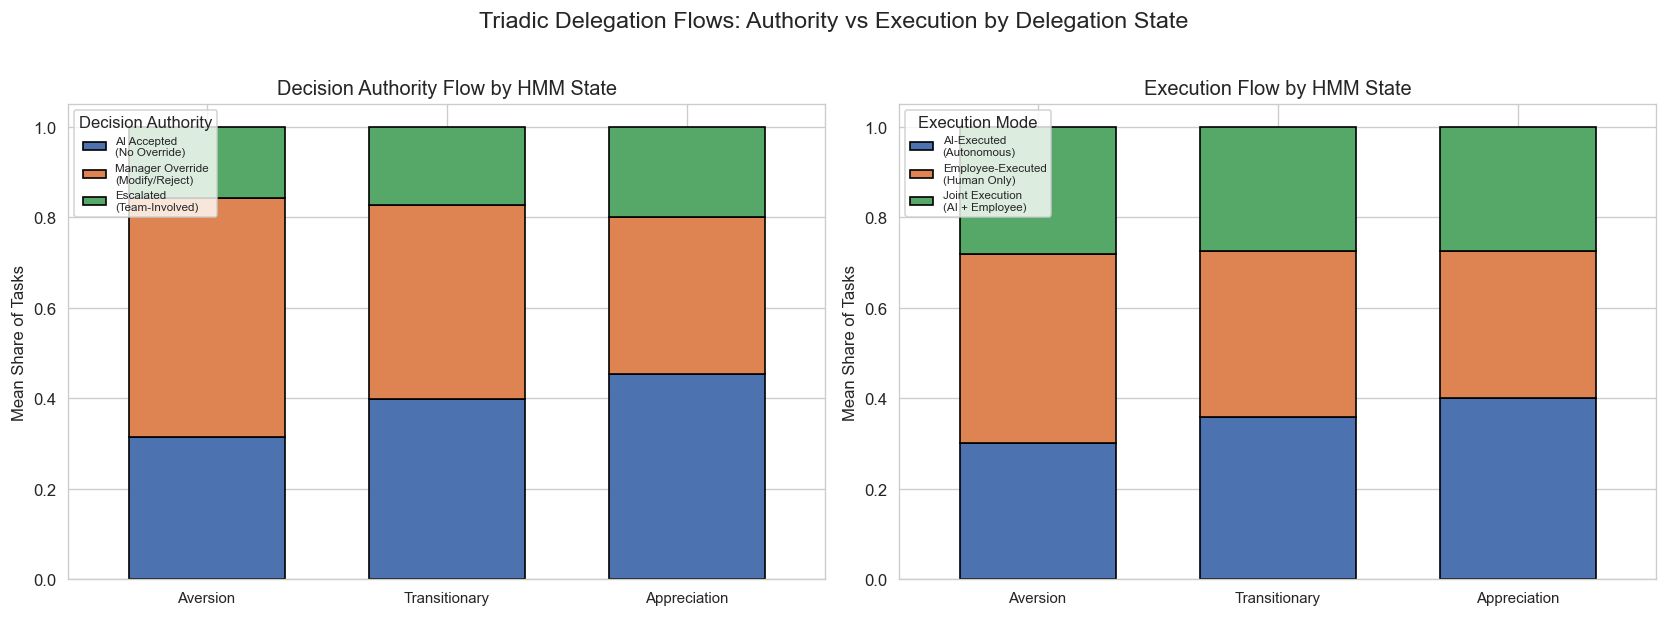


═══  Combined Authority × Execution Cross-Table by State  ═══

── Aversion ── (31,386 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6486,0.1026,0.2489
Manager Override,0.1013,0.6008,0.2979
Escalated (Team-Involved),0.2795,0.4390,0.2815



── Transitionary ── (72,006 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6524,0.1002,0.2474
Manager Override,0.1002,0.6004,0.2994
Escalated (Team-Involved),0.3255,0.3963,0.2782



── Appreciation ── (27,670 tasks)


,AI-Executed,Employee-Executed,Joint
Decision Authority,,,
AI Accepted (No Override),0.6508,0.1006,0.2486
Manager Override,0.0970,0.5983,0.3047
Escalated (Team-Involved),0.3635,0.3591,0.2774



═══  Mann-Whitney U: Authority AI Share Across States  ═══

H = 104.48, p = 0.000000

═══  Chi-Squared: Majority-AI-Authority × HMM State  ═══

χ² = 118.70, p = 0.000000, dof = 2

═══  Employee Override During Execution by State  ═══



,Mean Override Rate,Std,Count
state_label,,,
Aversion,0.0388,0.0302,749
Transitionary,0.0413,0.0316,1604
Appreciation,0.0413,0.0321,647


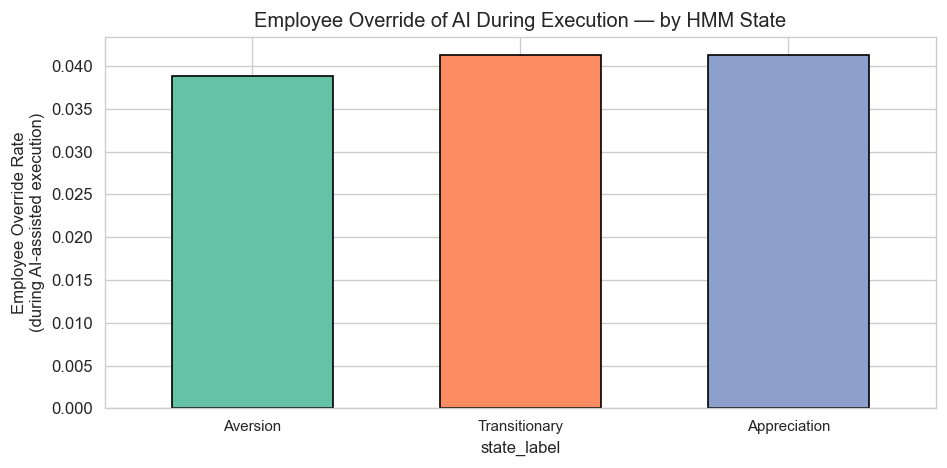


════════════════════════════════════════════════════════════
✓ Section 5.3 complete: Triadic delegation flows confirm that
  authority (who decides) and execution (who acts) are distinct
  dimensions that vary systematically across all three delegation states.
════════════════════════════════════════════════════════════


In [67]:
# ============================================================
# 5.3  Triadic Delegation Flows — Task-Level Evidence
# ============================================================
# Load task-level tables (decision_episode & execution_episode)
# and aggregate per manager-period for triadic flow analysis.
# ============================================================

print("═══  Loading Task-Level Episode Tables  ═══\n")

# ── 1. Load decision_episode ──
dec_ep = pd.read_excel(DATA_PATH, sheet_name="decision_episode")
print(f"decision_episode : {dec_ep.shape[0]:,} tasks  ({dec_ep.shape[1]} cols)")

# ── 2. Load execution_episode (read in chunks if heavy) ──
exec_ep = pd.read_excel(DATA_PATH, sheet_name="execution_episode", engine="openpyxl")
print(f"execution_episode: {exec_ep.shape[0]:,} tasks  ({exec_ep.shape[1]} cols)")

# ── 3. Create per-task AUTHORITY_ACTOR label ──
# Priority: escalation_flag first (team-involved), then manager_action
#   escalation_flag == 1          → "Escalated (Team-Involved)"
#   manager_action == "accept"    → "AI Accepted (No Override)"
#   manager_action ∈ modify/reject→ "Manager Override"
def map_authority(row):
    if row["escalation_flag"] == 1:
        return "Escalated (Team-Involved)"
    elif row["manager_action"] == "accept":
        return "AI Accepted (No Override)"
    else:  # reject or modify
        return "Manager Override"

dec_ep["authority_actor"] = dec_ep.apply(map_authority, axis=1)

# ── 4. Merge execution_mode onto decision_episode via episode_id ──
exec_mode = exec_ep[["episode_id", "execution_mode", "employee_override_during_execution"]].copy()
# Some episodes may have >1 execution (multiple employees); take mode
exec_mode_agg = (exec_mode
    .groupby("episode_id")
    .agg(execution_mode=("execution_mode", lambda x: x.mode().iloc[0]),
         any_emp_override=("employee_override_during_execution", "max"))
    .reset_index())

tasks = dec_ep.merge(exec_mode_agg, on="episode_id", how="left")
print(f"\nMerged task table: {tasks.shape[0]:,} rows")

# ── 5. Aggregate counts per manager-period ──
print("\n═══  Per Manager-Period Authority & Execution Counts  ═══\n")

auth_counts = (tasks
    .groupby(["manager_id", "period_id", "authority_actor"])
    .size()
    .unstack(fill_value=0)
    .reset_index())

# Ensure all authority columns present
for c in ["AI Accepted (No Override)", "Manager Override", "Escalated (Team-Involved)"]:
    if c not in auth_counts.columns:
        auth_counts[c] = 0

auth_counts.rename(columns={"AI Accepted (No Override)": "n_authority_ai",
                             "Manager Override": "n_authority_mgr",
                             "Escalated (Team-Involved)": "n_authority_escalated"}, inplace=True)
auth_counts["n_tasks_total"] = (auth_counts["n_authority_ai"]
                                + auth_counts["n_authority_mgr"]
                                + auth_counts["n_authority_escalated"])

exec_counts = (tasks
    .groupby(["manager_id", "period_id", "execution_mode"])
    .size()
    .unstack(fill_value=0)
    .reset_index())
exec_counts.columns.name = None

for c in ["ai", "human", "joint"]:
    if c not in exec_counts.columns:
        exec_counts[c] = 0

exec_counts.rename(columns={"ai": "n_exec_ai",
                             "human": "n_exec_employee",
                             "joint": "n_exec_joint"}, inplace=True)

# Merge authority + execution
task_agg = auth_counts.merge(exec_counts, on=["manager_id", "period_id"], how="outer").fillna(0)

# Compute shares
task_agg["share_authority_ai"]  = task_agg["n_authority_ai"]  / task_agg["n_tasks_total"]
task_agg["share_authority_mgr"] = task_agg["n_authority_mgr"] / task_agg["n_tasks_total"]
task_agg["share_authority_esc"] = task_agg["n_authority_escalated"] / task_agg["n_tasks_total"]

exec_total = task_agg["n_exec_ai"] + task_agg["n_exec_employee"] + task_agg["n_exec_joint"]
task_agg["share_exec_ai"]       = task_agg["n_exec_ai"]       / exec_total
task_agg["share_exec_employee"] = task_agg["n_exec_employee"] / exec_total
task_agg["share_exec_joint"]    = task_agg["n_exec_joint"]    / exec_total

print(task_agg[["manager_id", "period_id", "n_tasks_total",
                "share_authority_ai", "share_authority_mgr", "share_authority_esc",
                "share_exec_ai", "share_exec_employee", "share_exec_joint"]].head(8).to_string(index=False))

# ── 6. Link to HMM states ──
task_state = task_agg.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"], how="inner")

# Map state labels
task_state["state_label"] = task_state["most_likely_state"].map(STATE_LABELS)

print(f"\nTask-State merged: {task_state.shape[0]:,} manager-period obs with HMM state labels")

# ── 7. Authority Flow by HMM State ──
print("\n═══  Authority Flow Distribution by HMM State  ═══\n")

label_order = ["Aversion", "Transitionary", "Appreciation"]
auth_by_state = task_state.groupby("state_label")[
    ["share_authority_ai", "share_authority_mgr", "share_authority_esc"]
].mean().reindex(label_order)
auth_by_state.columns = ["AI Accepted\n(No Override)",
                         "Manager Override\n(Modify/Reject)",
                         "Escalated\n(Team-Involved)"]
display(auth_by_state.round(4))

# ── 8. Execution Flow by HMM State ──
print("\n═══  Execution Flow Distribution by HMM State  ═══\n")

exec_by_state = task_state.groupby("state_label")[
    ["share_exec_ai", "share_exec_employee", "share_exec_joint"]
].mean().reindex(label_order)
exec_by_state.columns = ["AI-Executed\n(Autonomous)",
                         "Employee-Executed\n(Human Only)",
                         "Joint Execution\n(AI + Employee)"]
display(exec_by_state.round(4))

# ── 9. Visualisation: Stacked Bar Charts ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Authority flows
auth_by_state.plot(kind="bar", stacked=True, ax=axes[0],
                   color=["#4C72B0", "#DD8452", "#55A868"],
                   edgecolor="k", width=0.65)
axes[0].set_title("Decision Authority Flow by HMM State", fontsize=12)
axes[0].set_ylabel("Mean Share of Tasks")
axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[0].legend(title="Decision Authority", fontsize=7, loc="upper left")
axes[0].set_ylim(0, 1.05)

# Execution flows
exec_by_state.plot(kind="bar", stacked=True, ax=axes[1],
                   color=["#4C72B0", "#DD8452", "#55A868"],
                   edgecolor="k", width=0.65)
axes[1].set_title("Execution Flow by HMM State", fontsize=12)
axes[1].set_ylabel("Mean Share of Tasks")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="center", fontsize=9)
axes[1].legend(title="Execution Mode", fontsize=7, loc="upper left")
axes[1].set_ylim(0, 1.05)

plt.suptitle("Triadic Delegation Flows: Authority vs Execution by Delegation State",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 10. Sankey-style summary table ──
print("\n═══  Combined Authority × Execution Cross-Table by State  ═══\n")

# Merge tasks with posteriors to get state_label on every individual task
tasks_with_state = tasks.merge(
    posteriors[["manager_id", "period_id", "most_likely_state"]],
    on=["manager_id", "period_id"], how="inner")
tasks_with_state["state_label"] = tasks_with_state["most_likely_state"].map(STATE_LABELS)

for sl in label_order:
    sub_tasks = tasks_with_state[tasks_with_state["state_label"] == sl]
    if sub_tasks.shape[0] == 0:
        continue
    cross = pd.crosstab(sub_tasks["authority_actor"], sub_tasks["execution_mode"],
                        normalize="index")
    cross.index.name = "Decision Authority"
    cross.columns.name = "Execution Mode"
    cross = cross.reindex(
        index=["AI Accepted (No Override)", "Manager Override", "Escalated (Team-Involved)"],
        columns=["ai", "human", "joint"]).fillna(0)
    cross.columns = ["AI-Executed", "Employee-Executed", "Joint"]
    print(f"── {sl} ── ({sub_tasks.shape[0]:,} tasks)")
    display(cross.round(4))
    print()

# ── 11. Statistical test: are authority flows different across states? ──
print("═══  Mann-Whitney U: Authority AI Share Across States  ═══\n")
from scipy.stats import mannwhitneyu as mwu_test, chi2_contingency

groups_auth = [g["share_authority_ai"].values
               for _, g in task_state.groupby("state_label")]
if len(groups_auth) == 2:
    u_stat_auth, p_auth = mwu_test(groups_auth[0], groups_auth[1], alternative="two-sided")
    print(f"U = {u_stat_auth:.2f}, p = {p_auth:.6f}")
    if p_auth < 0.05:
        print("  → Authority flows differ significantly across HMM states (p < 0.05)")
    else:
        print("  → Not significant at α=0.05")
else:
    from scipy.stats import kruskal
    kw_h, kw_p = kruskal(*groups_auth)
    print(f"H = {kw_h:.2f}, p = {kw_p:.6f}")

print("\n═══  Chi-Squared: Majority-AI-Authority × HMM State  ═══\n")
ct_auth = pd.crosstab(task_state["state_label"],
                       task_state.apply(
                           lambda r: "AI-Majority" if r["share_authority_ai"] > 0.5
                                     else "Non-AI-Majority", axis=1))
chi2, p_chi, dof, _ = chi2_contingency(ct_auth)
print(f"χ² = {chi2:.2f}, p = {p_chi:.6f}, dof = {dof}")

# ── 12. Employee override during execution by state ──
print("\n═══  Employee Override During Execution by State  ═══\n")

# Merge employee override rate
emp_override = tasks.groupby(["manager_id", "period_id"]).agg(
    emp_override_rate=("any_emp_override", "mean")
).reset_index()

task_state2 = task_state.merge(emp_override, on=["manager_id", "period_id"], how="left")

override_by_state = task_state2.groupby("state_label")["emp_override_rate"].agg(
    ["mean", "std", "count"]).reindex(label_order)
override_by_state.columns = ["Mean Override Rate", "Std", "Count"]
display(override_by_state.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
override_by_state["Mean Override Rate"].plot(
    kind="bar", ax=ax, color=sns.color_palette("Set2", best_J),
    edgecolor="k", width=0.6)
ax.set_ylabel("Employee Override Rate\n(during AI-assisted execution)")
ax.set_title("Employee Override of AI During Execution — by HMM State")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print("✓ Section 5.3 complete: Triadic delegation flows confirm that")
print("  authority (who decides) and execution (who acts) are distinct")
print("  dimensions that vary systematically across all three delegation states.")
print("═" * 60)

## 14. Temporal Evolution of Delegation Patterns

How does the share of tasks delegated to AI, retained by managers, or escalated to employees evolve across the 25 observation periods?

- **Delegated to AI** — AI recommendation accepted without override (`authority_actor = "AI Accepted (No Override)"`)
- **Retained by Manager** — Manager overrides the AI (`authority_actor = "Manager Override"`)
- **Escalated to Employees** — Decision escalated to team (`authority_actor = "Escalated (Team-Involved)"`)

We plot the **mean share across all managers** for each period, plus a 95 % confidence band.

═══  Delegation Shares Over Time (All Managers)  ═══



,Delegated to AI (mean),Retained by Manager (mean),Escalated to Employee (mean)
Period,,,
1,0.3033,0.4792,0.2175
2,0.2997,0.4889,0.2114
3,0.2919,0.4979,0.2102
4,0.2677,0.5151,0.2171
5,0.2772,0.5024,0.2204
6,0.2993,0.4955,0.2052
7,0.3091,0.4857,0.2051
8,0.2873,0.4993,0.2134
9,0.2810,0.5017,0.2173


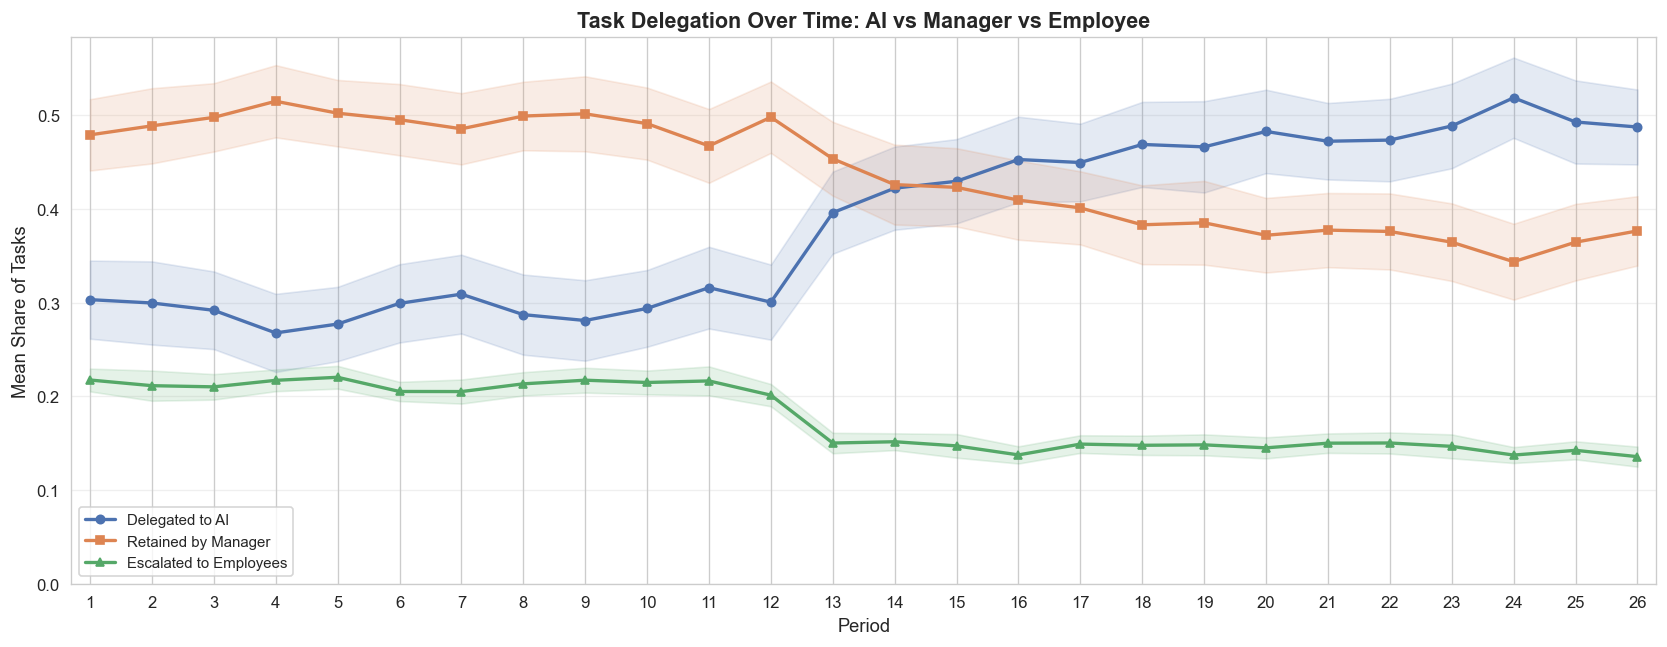

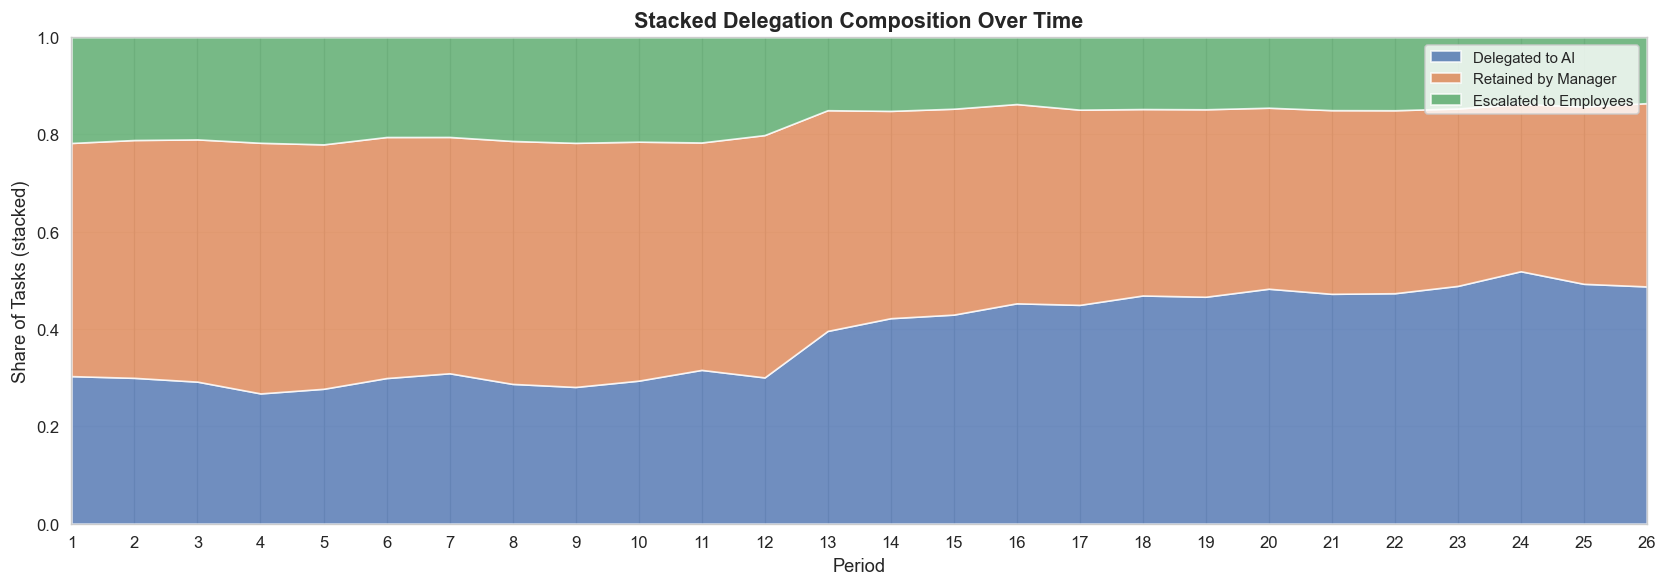

  AI delegation              ρ = +0.912  p = 0.0000  ***
  Manager retention          ρ = -0.886  p = 0.0000  ***
  Employee escalation        ρ = -0.861  p = 0.0000  ***

════════════════════════════════════════════════════════════
✓ Section 5.4 complete: Temporal delegation trends visualised.
════════════════════════════════════════════════════════════


In [68]:
# ============================================================
# 5.4  Task Delegation Over Time
# ============================================================
# Aggregate authority shares across all managers per period,
# then plot temporal evolution with confidence bands.
# ============================================================

print("═══  Delegation Shares Over Time (All Managers)  ═══\n")

# ── 1. Period-level aggregation ──
time_agg = (task_agg
    .groupby("period_id")[["share_authority_ai", "share_authority_mgr", "share_authority_esc"]]
    .agg(["mean", "std", "count"]))

# Flatten multi-index columns
periods_t = time_agg.index.values

ai_mean  = time_agg[("share_authority_ai",  "mean")].values
mgr_mean = time_agg[("share_authority_mgr", "mean")].values
esc_mean = time_agg[("share_authority_esc", "mean")].values

ai_se  = time_agg[("share_authority_ai",  "std")].values / np.sqrt(time_agg[("share_authority_ai",  "count")].values)
mgr_se = time_agg[("share_authority_mgr", "std")].values / np.sqrt(time_agg[("share_authority_mgr", "count")].values)
esc_se = time_agg[("share_authority_esc", "std")].values / np.sqrt(time_agg[("share_authority_esc", "count")].values)

# Summary table
time_summary = pd.DataFrame({
    "Period": periods_t,
    "Delegated to AI (mean)": ai_mean,
    "Retained by Manager (mean)": mgr_mean,
    "Escalated to Employee (mean)": esc_mean,
}).set_index("Period")
display(time_summary.round(4))

# ── 2. Line plot with 95% CI bands ──
fig, ax = plt.subplots(figsize=(14, 5.5))

z = 1.96  # 95% CI

# Delegated to AI
ax.plot(periods_t, ai_mean, "-o", color="#4C72B0", linewidth=2, markersize=5,
        label="Delegated to AI")
ax.fill_between(periods_t, ai_mean - z * ai_se, ai_mean + z * ai_se,
                color="#4C72B0", alpha=0.15)

# Retained by Manager
ax.plot(periods_t, mgr_mean, "-s", color="#DD8452", linewidth=2, markersize=5,
        label="Retained by Manager")
ax.fill_between(periods_t, mgr_mean - z * mgr_se, mgr_mean + z * mgr_se,
                color="#DD8452", alpha=0.15)

# Escalated to Employees
ax.plot(periods_t, esc_mean, "-^", color="#55A868", linewidth=2, markersize=5,
        label="Escalated to Employees")
ax.fill_between(periods_t, esc_mean - z * esc_se, esc_mean + z * esc_se,
                color="#55A868", alpha=0.15)

ax.set_xlabel("Period", fontsize=11)
ax.set_ylabel("Mean Share of Tasks", fontsize=11)
ax.set_title("Task Delegation Over Time: AI vs Manager vs Employee",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="best")
ax.set_xlim(periods_t.min() - 0.3, periods_t.max() + 0.3)
ax.set_ylim(0, None)
ax.set_xticks(periods_t)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. Stacked area chart ──
fig2, ax2 = plt.subplots(figsize=(14, 5))

ax2.stackplot(periods_t, ai_mean, mgr_mean, esc_mean,
              labels=["Delegated to AI", "Retained by Manager", "Escalated to Employees"],
              colors=["#4C72B0", "#DD8452", "#55A868"], alpha=0.8)

ax2.set_xlabel("Period", fontsize=11)
ax2.set_ylabel("Share of Tasks (stacked)", fontsize=11)
ax2.set_title("Stacked Delegation Composition Over Time",
              fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim(periods_t.min(), periods_t.max())
ax2.set_ylim(0, 1.0)
ax2.set_xticks(periods_t)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. Trend test (Spearman rank correlation with period) ──
from scipy.stats import spearmanr

for label, vals in [("AI delegation", ai_mean),
                    ("Manager retention", mgr_mean),
                    ("Employee escalation", esc_mean)]:
    rho, p_val = spearmanr(periods_t, vals)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"  {label:25s}  ρ = {rho:+.3f}  p = {p_val:.4f}  {sig}")

print("\n" + "═" * 60)
print("✓ Section 5.4 complete: Temporal delegation trends visualised.")
print("═" * 60)